In [1]:
import anndata as ad
from statsmodels.stats.multitest import multipletests 
from statannotations.Annotator import Annotator
import matplotlib
import scanpy as sc
import scanpy.external as sce
import gseapy
import colorcet as cc
from utils import *
from first_part import *
from matplotlib_venn import venn3, venn2
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
import decoupler as dc
atac_input_file_name = "/Users/eloiseberson/Documents/atac_pd/spor_gba1_lrrk2_bulk.csv"
outdir = "./outdir/"

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packag

In [12]:
import matplotlib
gseapy.__version__

'1.1.4'

In [5]:
##Load data
atac_input_file_name = "/Users/eloiseberson/Documents/atac_pd/spor_gba1_lrrk2_bulk.csv"
peak_annot_path = "/Users/eloiseberson/Documents/atac_pd/_annot_chipseeker.tsv"
deconv_path = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Nov24.h5ad"
adata = prepareDataBulk(atac_input_file_name, deconv_path,peak_annot_path)
adata

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 153 × 141808
    obs: 'filename', 'Sample_num', 'brain_region', 'Group', 'PatientID', 'Neuritic plaque density binary', 'Braak score NFT binary', 'xxx.Braak score', 'xxx.Unified LB Stage', 'AD path', 'PD clinical', 'Neocortical LB', 'Brainstem/Limbic LB', 'ApoE_4', 'ApoE_2', 'Cognitive Imp', 'PD path', 'Sex', 'ApoE', 'age at death', 'group', 'MutationType', 'ADNC', 'CI', 'Braak Score', 'LB Stages', 'Total path'
    var: 'peakid', 'seqnames', 'start', 'end', 'width', 'strand', 'V4', 'annotation', 'geneChr', 'geneStart', 'geneEnd', 'geneLength', 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL', 'SYMBOL', 'GENENAME'

In [6]:
adata

AnnData object with n_obs × n_vars = 153 × 141808
    obs: 'filename', 'Sample_num', 'brain_region', 'Group', 'PatientID', 'Neuritic plaque density binary', 'Braak score NFT binary', 'xxx.Braak score', 'xxx.Unified LB Stage', 'AD path', 'PD clinical', 'Neocortical LB', 'Brainstem/Limbic LB', 'ApoE_4', 'ApoE_2', 'Cognitive Imp', 'PD path', 'Sex', 'ApoE', 'age at death', 'group', 'MutationType', 'ADNC', 'CI', 'Braak Score', 'LB Stages', 'Total path'
    var: 'peakid', 'seqnames', 'start', 'end', 'width', 'strand', 'V4', 'annotation', 'geneChr', 'geneStart', 'geneEnd', 'geneLength', 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL', 'SYMBOL', 'GENENAME'

In [7]:
adata.var_names = adata.var_names.astype(str)
adata.X = adata.X.astype(float)
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

Number of peaks needed to explain 50% of variance: 31,706
Number of peaks needed to explain 80% of variance: 73,687
Number of peaks needed to explain 90% of variance: 96,943
Number of peaks needed to explain 95% of variance: 112,912
Number of peaks needed to explain 99% of variance: 131,884
131884.0


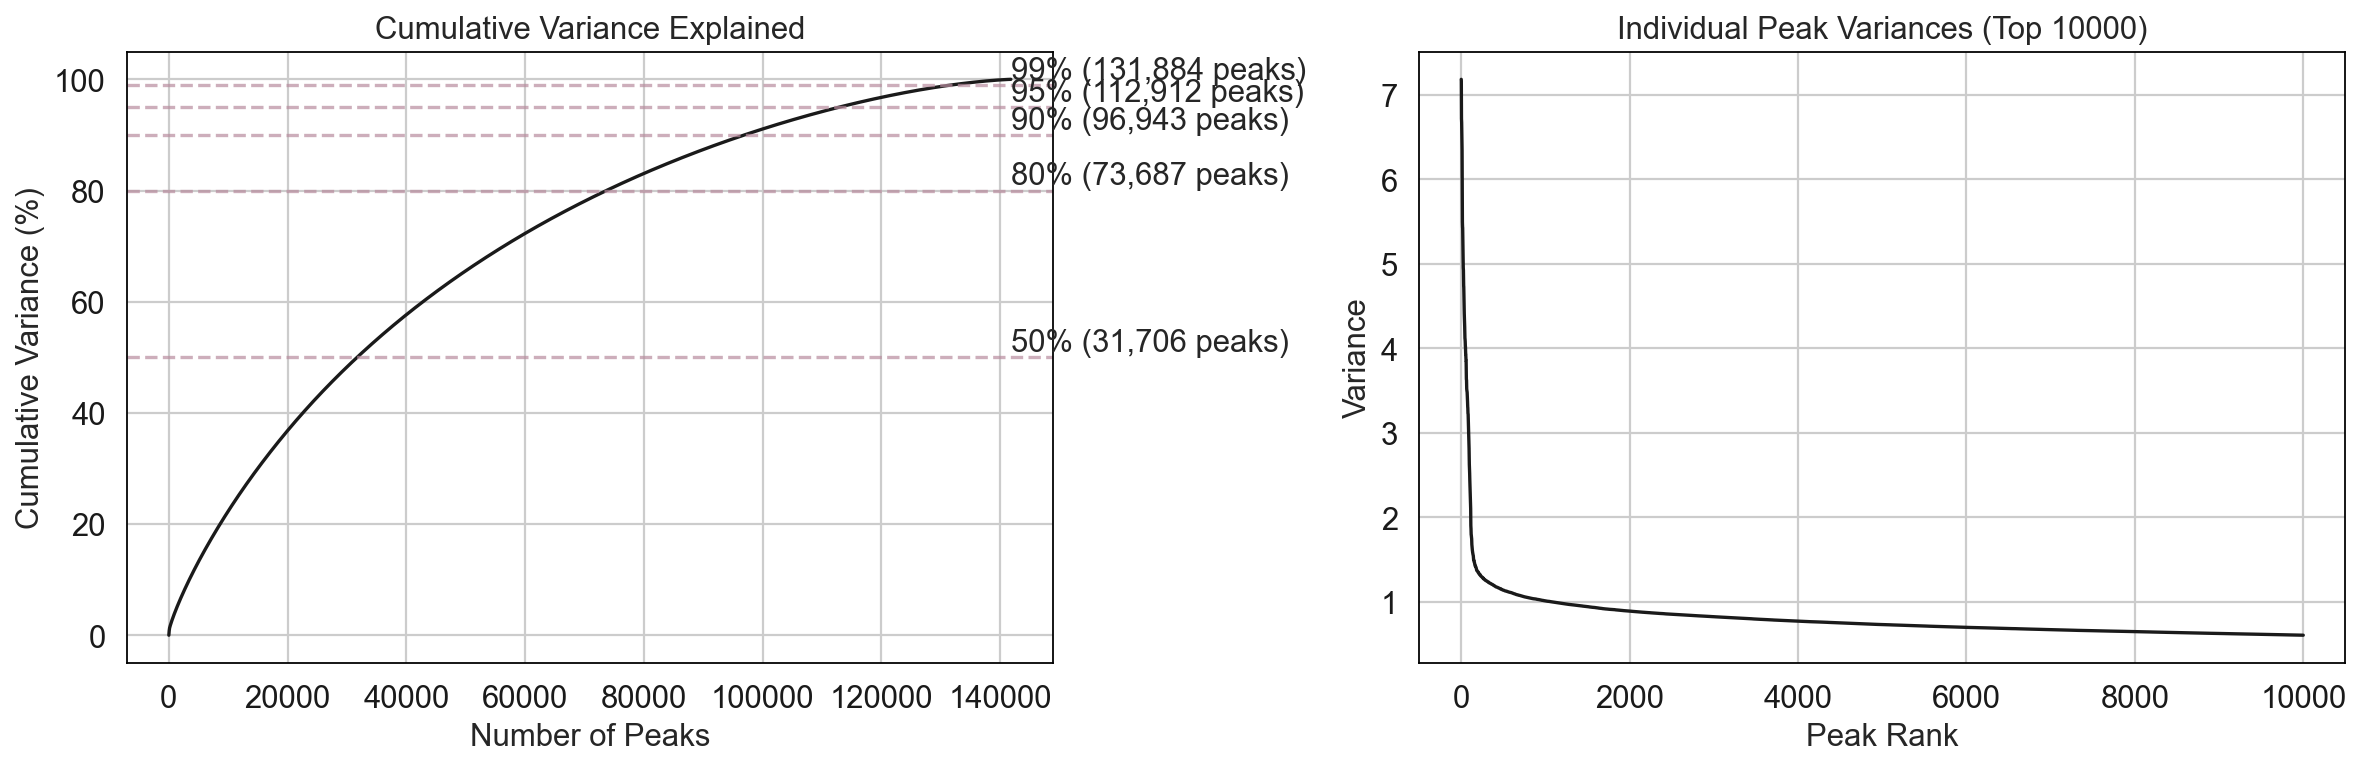

In [87]:
# Use the functions
variance_df = calculate_cumulative_variance(adata)
adata.var["peak_variance"] = adata.X.var(axis=0)
fig = plot_variance_metrics(variance_df)
plt.savefig("./outdir/lineplot_variance_bulk_analysis.svg")
# Print the number of peaks needed for different variance thresholds
thresholds = [50, 80, 90, 95,99]
for threshold in thresholds:
    n_peaks = variance_df[variance_df['cumulative_variance'] >= threshold].iloc[0]['n_peaks']
    print(f"Number of peaks needed to explain {threshold}% of variance: {n_peaks:,.0f}")

# You can then select the number of peaks based on your chosen threshold
# For example, to keep peaks explaining 80% of variance:
threshold = 99
n_peaks_to_keep = variance_df[variance_df['cumulative_variance'] >= threshold].iloc[0]['n_peaks']
top_peaks = adata.var.sort_values('peak_variance', ascending=False).index[:int(n_peaks_to_keep)]
adata = adata[:, top_peaks]
print(n_peaks_to_keep)

In [88]:
n_peaks_to_keep = 131884

In [89]:
adata[adata.obs.group=="GBA1"].obs.MutationType.unique()
adata.obs["Mutation Group"] = adata.obs["MutationType"].replace({"T369M, V447E":"T369M",
                                                                   "T369M, C342": "T369M",
                                                                 "N370S/N370S":"N370S",
                                                                })
adata

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_56657/901823062.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["Mutation Group"] = adata.obs["MutationType"].replace({"T369M, V447E":"T369M",
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 153 × 131884
    obs: 'filename', 'Sample_num', 'brain_region', 'Group', 'PatientID', 'Neuritic plaque density binary', 'Braak score NFT binary', 'xxx.Braak score', 'xxx.Unified LB Stage', 'AD path', 'PD clinical', 'Neocortical LB', 'Brainstem/Limbic LB', 'ApoE_4', 'ApoE_2', 'Cognitive Imp', 'PD path', 'Sex', 'ApoE', 'age at death', 'group', 'MutationType', 'ADNC', 'CI', 'Braak Score', 'LB Stages', 'Total path', 'Mutation Group'
    var: 'peakid', 'seqnames', 'start', 'end', 'width', 'strand', 'V4', 'annotation', 'geneChr', 'geneStart', 'geneEnd', 'geneLength', 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL', 'SYMBOL', 'GENENAME', 'peak_variance'
    uns: 'log1p'

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


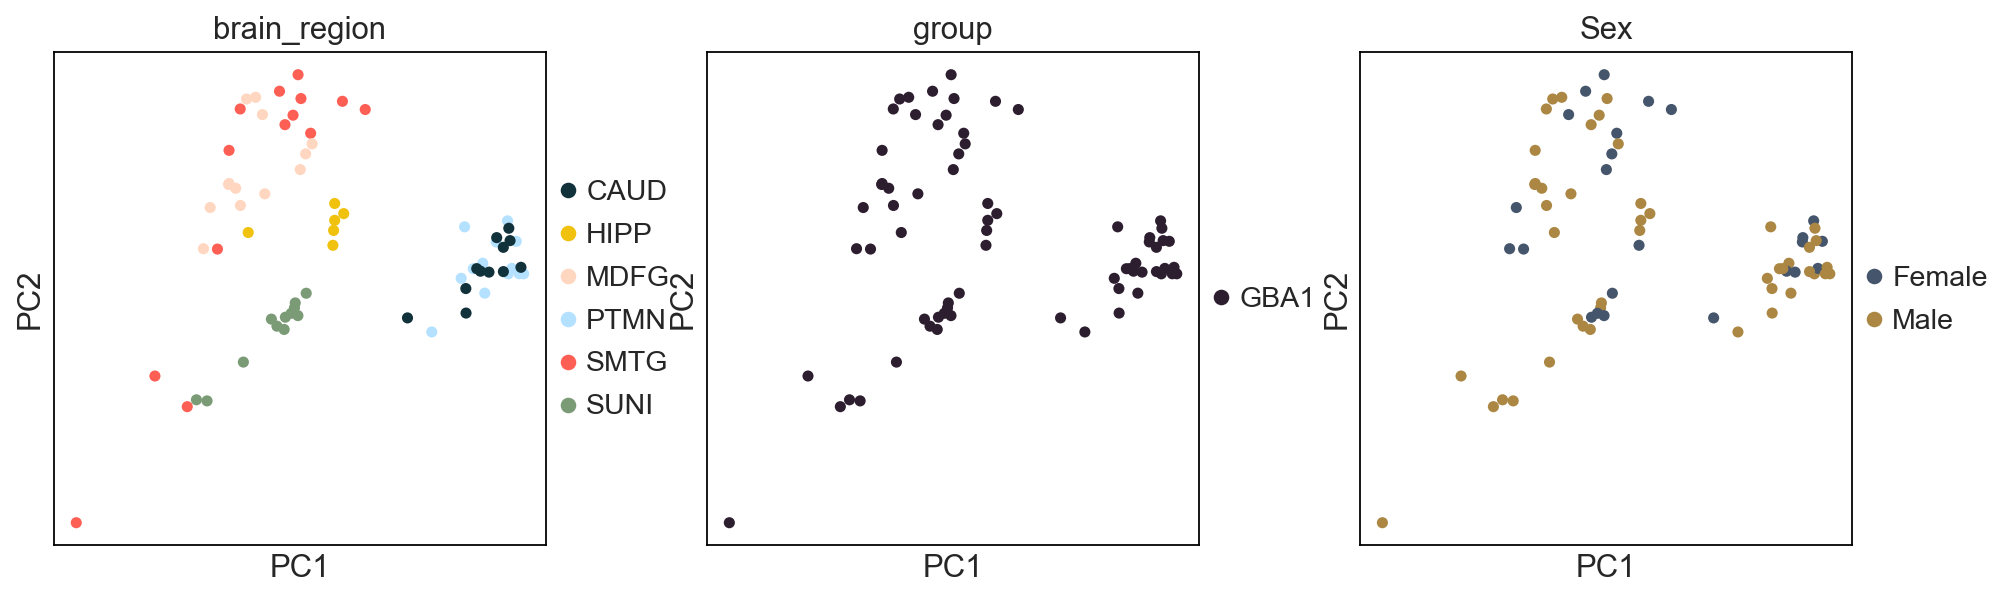

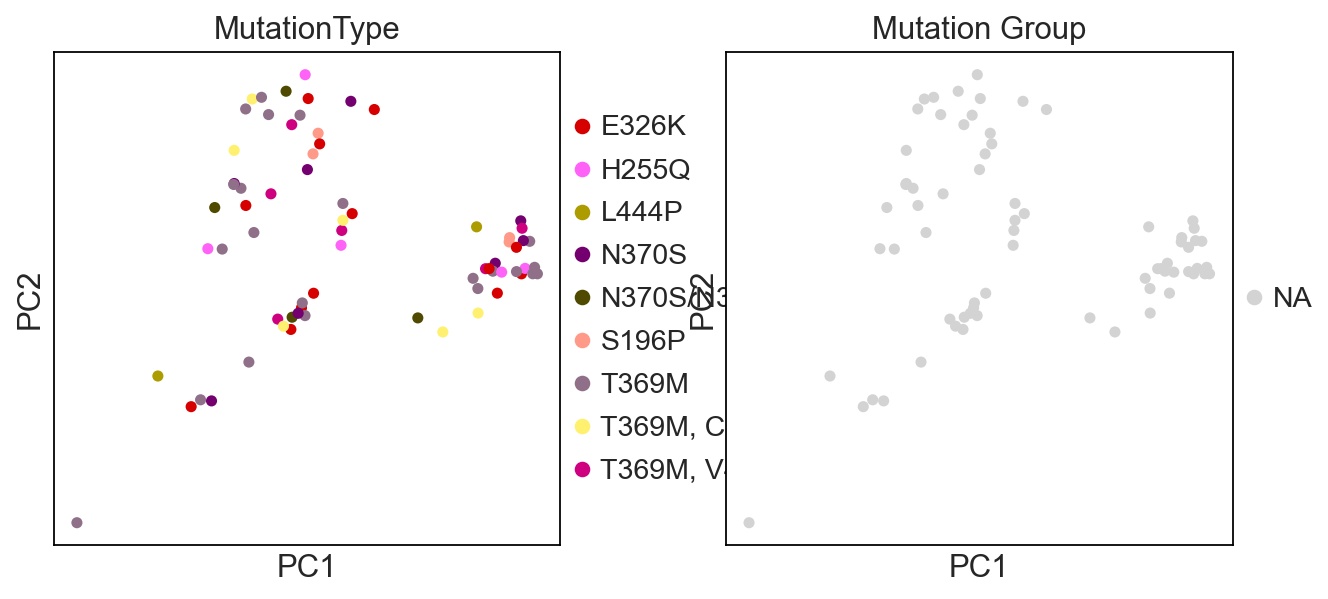

In [90]:
adata.obs_names = adata.obs_names.astype(str)
adata_gba1 = adata[adata.obs.group=="GBA1"]
adata_gba1.obs.groupby(["MutationType"]).PatientID.nunique()

# sc.pp.normalize_total(adata_gba1)
# sc.pp.log1p(adata_gba1)
sc.tl.pca(adata_gba1)
sc.pl.pca(adata_gba1, color=['brain_region','group','Sex'], palette=COLORS_CT,s=100)
sc.pl.pca(adata_gba1, color=['MutationType', 'Mutation Group'], s=100, palette=cc.glasbey_warm)

In [91]:
# adata_gba1.obs.groupby(["MutationType"]).PatientID.nunique()
adata.obs["Mutation Group"] = adata.obs["MutationType"].replace({"T369M, V447E":"T369M",
                                                                   "T369M, C342": "T369M",
                                                                 "N370S/N370S":"N370S",
                                                     
                                                                })


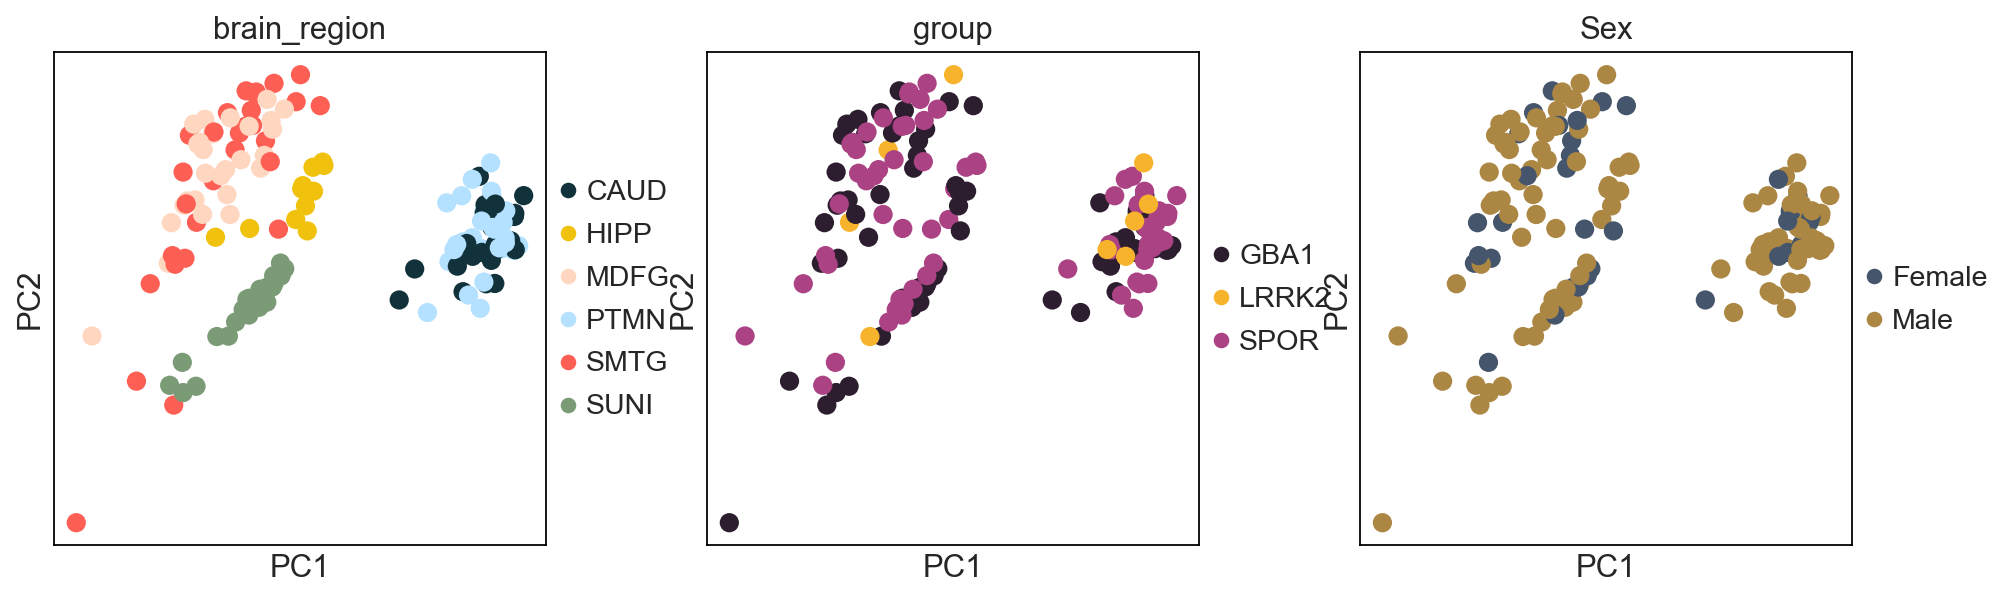

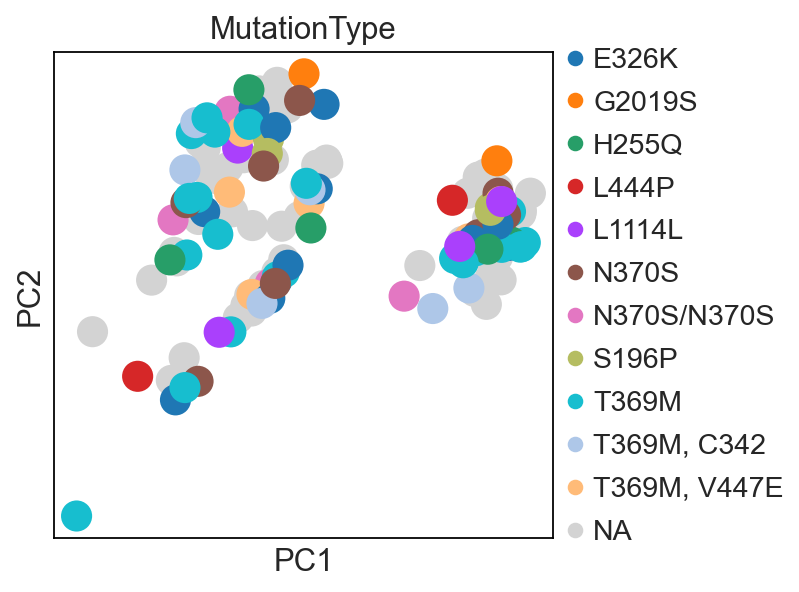

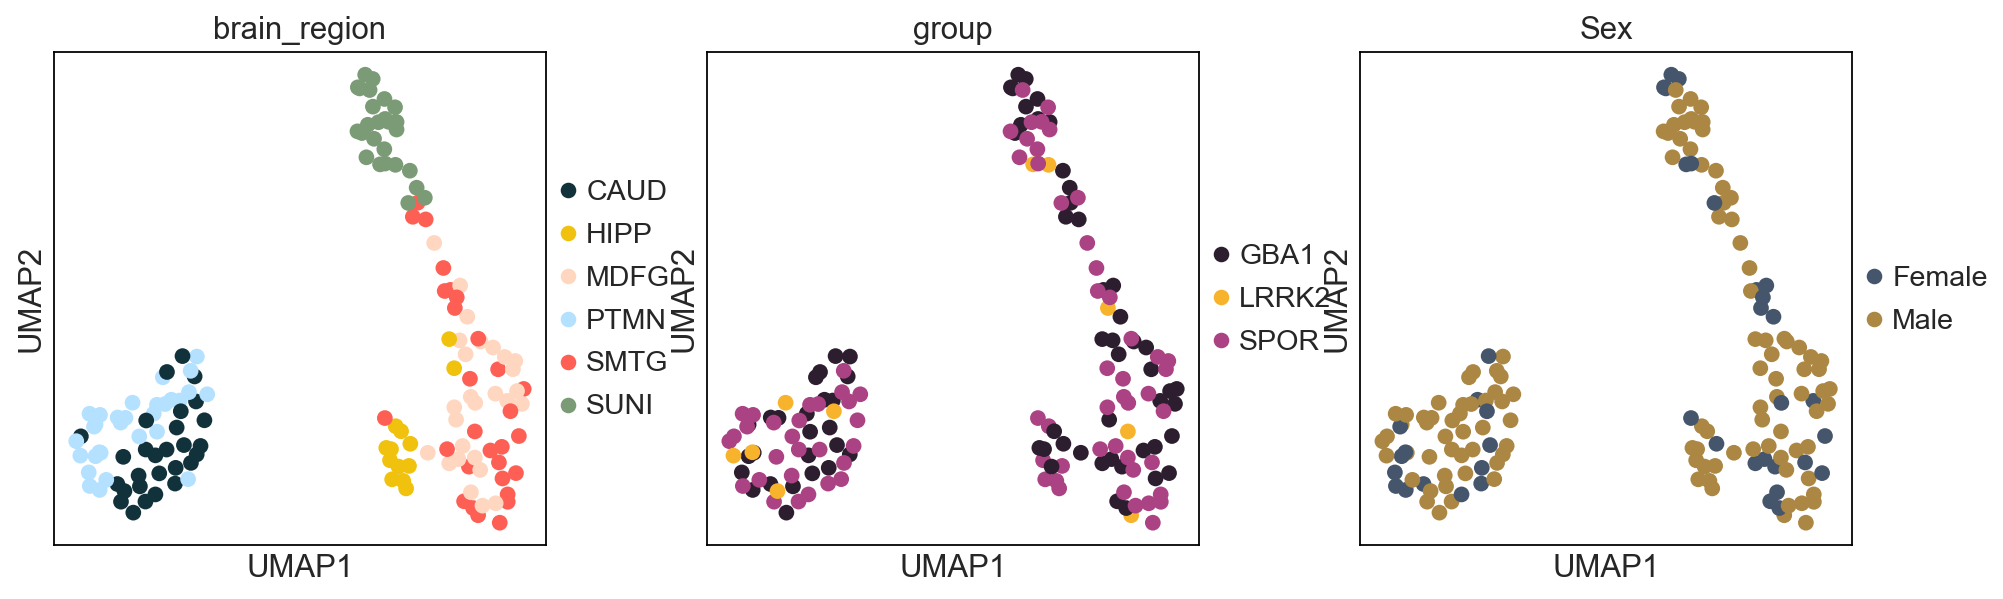

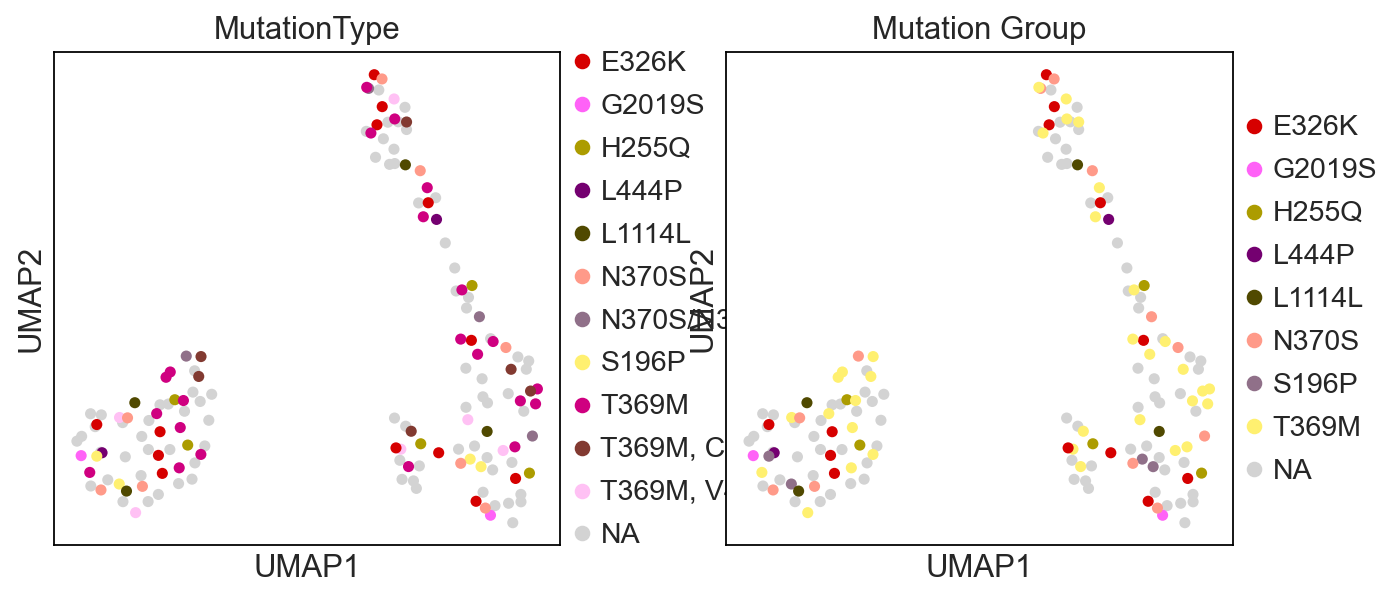

In [92]:
sc.set_figure_params(format='svg')
sc.tl.pca(adata)
sc.pl.pca(adata, color=['brain_region','group',"Sex"], palette=COLORS_CT,s=300,save="PCA_bulk_gba1_spor.svg")
sc.pl.pca(adata, color=['MutationType'])
sc.pp.neighbors(adata,n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['brain_region','group',"Sex"], palette=COLORS_CT,s=200)
sc.pl.umap(adata, color=['MutationType', 'Mutation Group'], s=100, palette=cc.glasbey_warm)

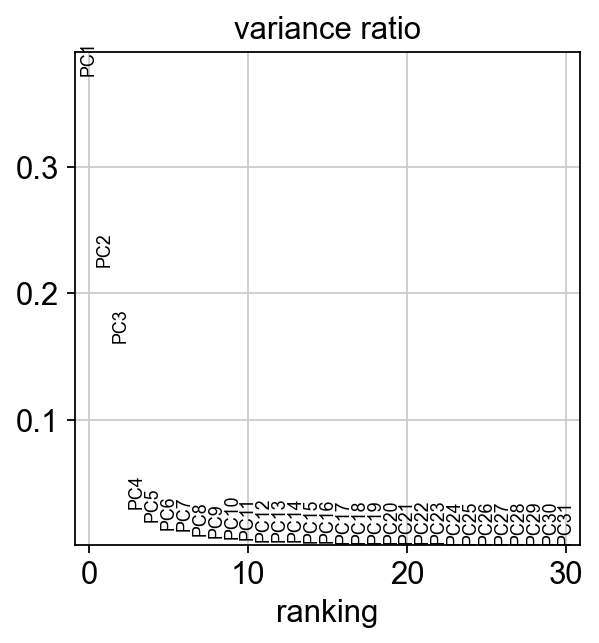

In [12]:
sc.pl.pca_variance_ratio(adata)

In [20]:
adata.obs["LB"] = adata.obs["PD path"]
adata.obs["Phenotype"] = adata.obs["group"].tolist()
adata.obs["Brain_region"] = adata.obs["brain_region"].tolist()
adata.obs["APOE_E4"] = adata.obs["ApoE_4"].tolist()
adata.obs["APOE_E2"] = adata.obs["ApoE_2"].tolist()
dc.get_metadata_associations(
    adata,
    obs_keys = ['Phenotype','Sex', 'Brain_region','ADNC','LB','CI', 'APOE_E4',"APOE_E2"],  # Metadata columns to associate to PCs
    obsm_key='X_pca',  # Where the PCs are stored
    uns_key='pca_anova',  # Where the results are stored
    inplace=True,
)

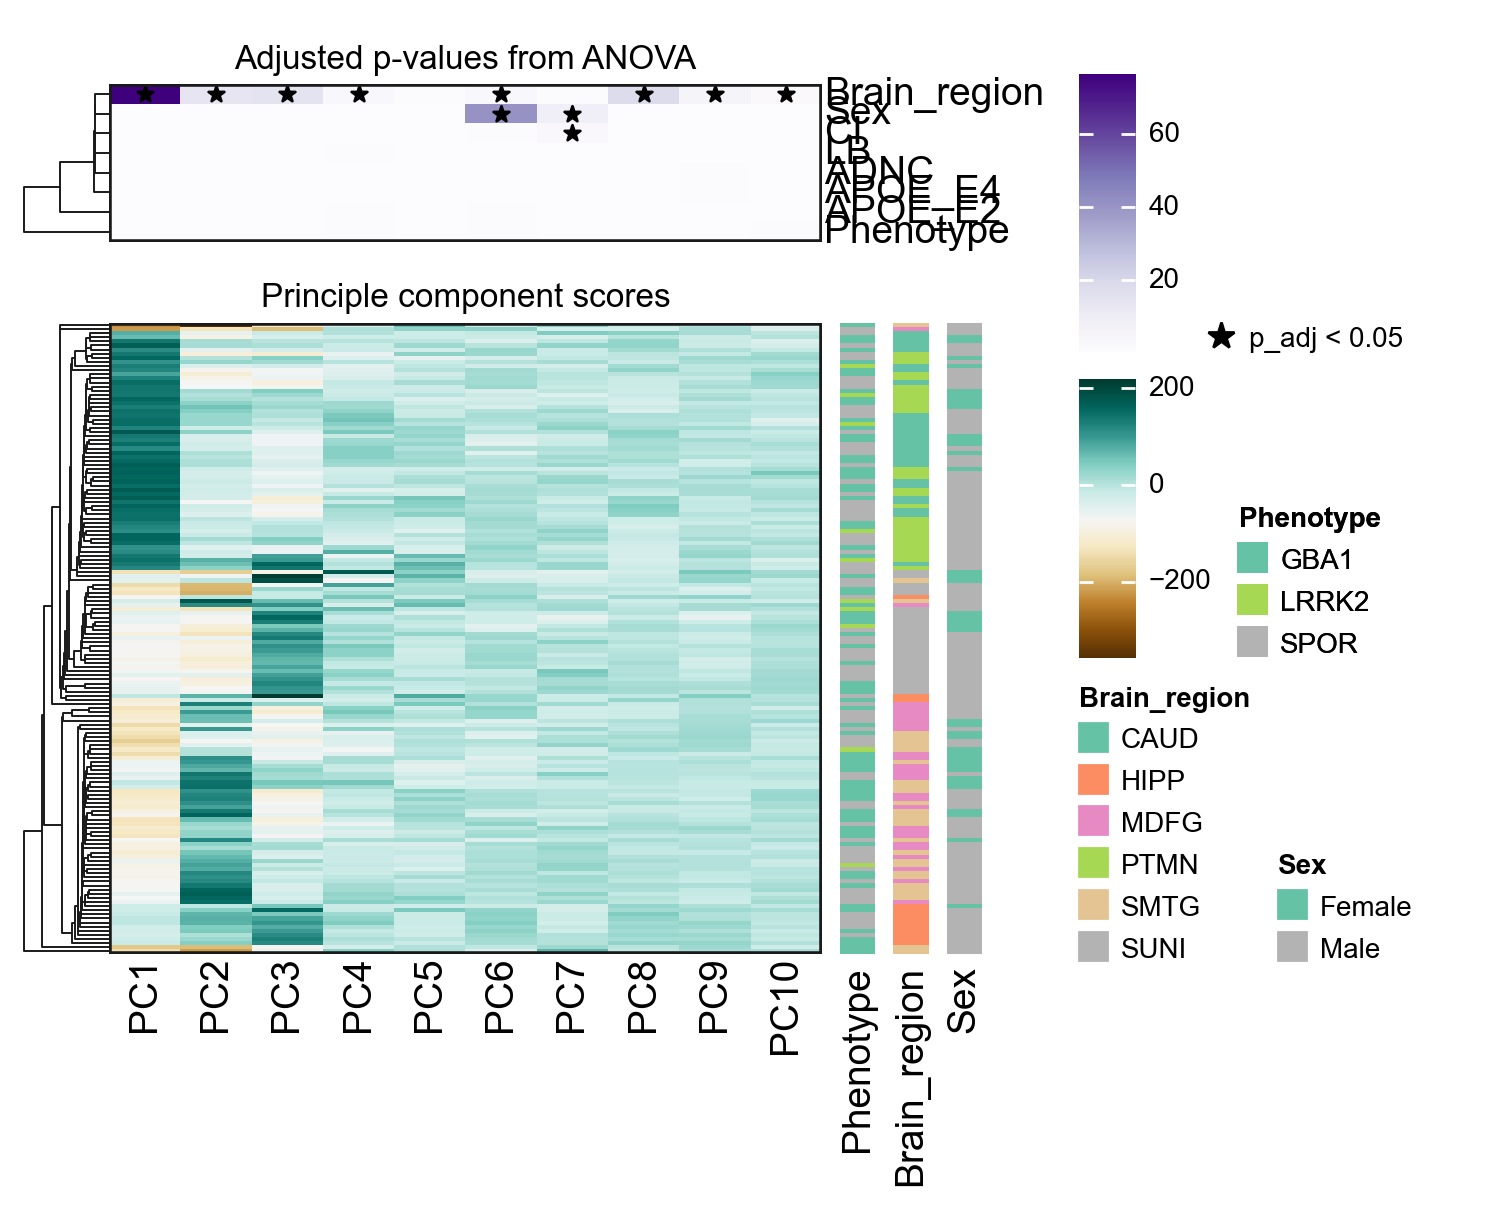

In [27]:

dc.plot_associations(
    adata,
    uns_key='pca_anova',  # Summary statistics from the anova tests
    obsm_key='X_pca',  # where the PCs are stored
    stat_col='p_adj',  # Which summary statistic to plot
    obs_annotation_cols = ['Phenotype','Brain_region', 'Sex'], # which sample annotations to plot
    titles=['Principle component scores', 'Adjusted p-values from ANOVA'],
    figsize=(7, 5),
    n_factors=10,
    # cmap=cmap
)

In [29]:
dico_per = {k:str(np.round(it*100,1))+"%" for k, it in enumerate(adata.uns["pca"]["variance_ratio"])}

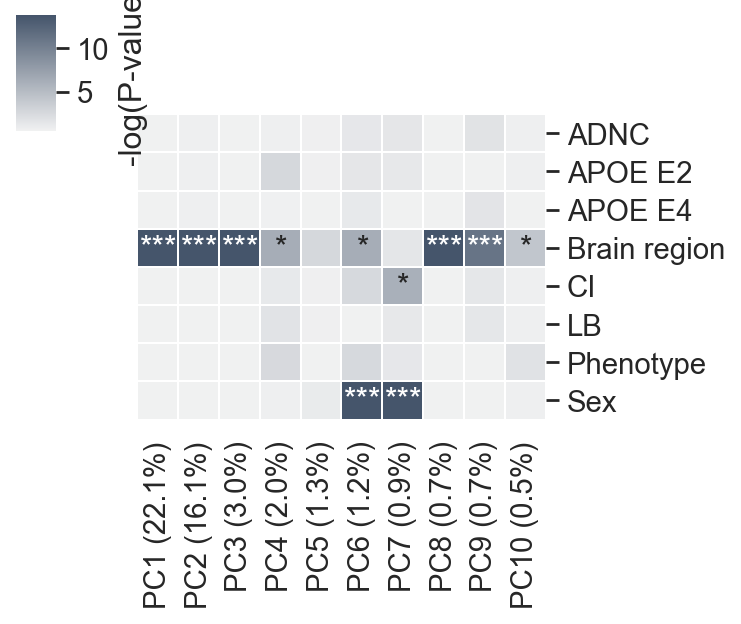

In [30]:
adata.uns["pca_anova"]["p_adj"] +=1e-6
adata.uns["pca_anova"]["-log(q)"] = -np.log(adata.uns["pca_anova"]["p_adj"])
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
sns.set(style="white", font_scale=1.2)
# Colors
def pval_f(x):
    if x<=0.0001:
        return "***"
    elif x<=0.001:
        return "**"
    # elif x<= 0.01:
    #     return "**"
    elif x<=0.05:
        return "*"
    else:
        return ""
toplot = adata.uns["pca_anova"]
toplot["variable"] = toplot["variable"].replace({"celltypes":"Cell type", "age_death":"Age",
                                                 "Brain_region":"Brain region","diagnosis":"Diagnosis",
                                                 "APOE_E4":"APOE E4", "APOE_E2":"APOE E2"})
# toplot= toplot.sort_values(["variable"])

mat = toplot.pivot_table(index="variable", columns="factor", values="-log(q)")
mat = mat.loc[:, ["PC%s"%k for k in range(1,11)]]
mat.columns = [it+ " (" + dico_per[int(it.split("PC")[1])] + ")" for it in mat.columns.tolist()]

mat2 = toplot.pivot_table(index="variable", columns="factor", values="p_adj")
mat2 = mat2.loc[:, ["PC%s"%k for k in range(1,11)]]
mat2.columns = [it+ " (" + dico_per[int(it.split("PC")[1])] + ")" for it in mat2.columns.tolist()]

annot = mat2.copy()
for it in mat2.columns.tolist():
    annot[it] = annot[it].apply(lambda x: pval_f(x)).tolist()
ax = sns.clustermap(mat, annot=annot, fmt="s", cmap=cmap,row_cluster=False, col_cluster=False,
               figsize=(5,4),
               linewidth=0.2,
               cbar_kws={'label': '-log(P-value)'},vmin=0.5)
ax.ax_heatmap.set_ylabel("")
ax.ax_heatmap.set_xlabel("")

plt.savefig("./outdir/heatmap_anova_bulk.svg")

In [31]:
toplot

,variable,pval,eta_sq,factor,p_adj,-log(q)
0,Phenotype,6.255828e-01,0.006235,PC1,0.952935,0.048209
1,Sex,9.289109e-01,0.000053,PC1,0.952935,0.048209
2,Brain region,6.827536e-78,0.917904,PC1,0.000001,13.815511
3,ADNC,6.691984e-01,0.001212,PC1,0.952935,0.048209
4,LB,7.417473e-01,0.000778,PC1,0.952935,0.048209
...,...,...,...,...,...,...
395,ADNC,2.683404e-01,0.008108,PC50,0.589837,0.527909
396,LB,2.853590e-01,0.008149,PC50,0.589837,0.527909
397,CI,4.104016e-01,0.004492,PC50,0.589837,0.527909
398,APOE E4,4.423772e-01,0.003913,PC50,0.589837,0.527909


In [32]:
adata

AnnData object with n_obs × n_vars = 153 × 123694
    obs: 'filename', 'Sample_num', 'brain_region', 'Group', 'PatientID', 'Neuritic plaque density binary', 'Braak score NFT binary', 'xxx.Braak score', 'xxx.Unified LB Stage', 'AD path', 'PD clinical', 'Neocortical LB', 'Brainstem/Limbic LB', 'ApoE_4', 'ApoE_2', 'Cognitive Imp', 'PD path', 'Sex', 'ApoE', 'age at death', 'group', 'MutationType', 'ADNC', 'CI', 'Braak Score', 'LB Stages', 'Total path', 'Mutation Group', 'LB', 'Phenotype', 'Brain_region', 'APOE_E4', 'APOE_E2'
    var: 'peakid', 'seqnames', 'start', 'end', 'width', 'strand', 'V4', 'annotation', 'geneChr', 'geneStart', 'geneEnd', 'geneLength', 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL', 'SYMBOL', 'GENENAME', 'peak_variance'
    uns: 'log1p', 'pca', 'brain_region_colors', 'group_colors', 'Sex_colors', 'MutationType_colors', 'neighbors', 'umap', 'Mutation Group_colors', 'pca_anova'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'conne

# DE SPOR vs GBA1 per brain region

In [33]:
#DE SPOR & GBA1 PD+
atac_input_file_name = "/Users/eloiseberson/Documents/atac_pd/spor_gba1_lrrk2_bulk.csv"
peak_annot_path = "/Users/eloiseberson/Documents/atac_pd/_annot_chipseeker.tsv"
deconv_path = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Nov24.h5ad"
adata = prepareDataBulk(atac_input_file_name, deconv_path,peak_annot_path)
adata
adata.obs["celltype"] = "Bulk"
adata.obs["condition"] = adata.obs["group"].values
adata.obs["LB"] = adata.obs["PD path"].values
adata.obs_names = adata.obs_names.astype(str)
adata.var_names = adata.var_names.astype(str)
method = 'pydeseq2_sex_adjusted_no_refit_bulk'
condition = "group"
adata.var['peak_variance'] = adata.X.var(axis=0)
top_peaks = adata.var.sort_values('peak_variance', ascending=False).index[:int(n_peaks_to_keep)]
filtered_adata = adata[:, top_peaks]
peaks_df = differential_expression(adata, 0, method, corr_=["Sex"], columns=condition)
peaks_df
peaks_df.to_pickle("./res_DE_%s_%s_bulk.pickle"%(method,condition))

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


ok
PTMN_Bulk
PTMN_Bulk DE analysis
SPOR$GBA1
group
GBA1    13
SPOR    14
dtype: int64
(27, 141808)


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/frame.py:6479: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  new_obj.index = new_index
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 0.12 seconds.

Fitting dispersions...
... done in 12.10 seconds.

Fitting dispersion trend curve...
... done in 1.47 seconds.

Fitting MAP dispersions...
... done in 14.32 seconds.

Fitting LFCs...
... done in 5.23 seconds.

Calculating cook's distance..

Log2 fold change & Wald test p-value: group GBA1 vs SPOR
                             baseMean  log2FoldChange     lfcSE      stat  \
chr1.190450.192065      794352.032215        0.141676  0.231443  0.612144   
chr1.267874.268152       48886.073753        0.338003  0.201812  1.674842   
chr1.777855.780082      795146.167645       -0.077149  0.178831 -0.431407   
chr1.826642.828059      354973.800718       -0.072181  0.173757 -0.415412   
chr1.849559.850830       77983.928309       -0.077989  0.195659 -0.398596   
...                               ...             ...       ...       ...   
chrY.26352699.26354781  227178.056408       -0.969934  0.842007 -1.151931   
chrY.26359586.26360822  117979.300200       -0.107767  0.560640 -0.192221   
chrY.26669762.26671930  380381.136023       -0.173495  0.784283 -0.221215   
chrY.56677051.56678886   62544.861332       -0.471862  0.534195 -0.883313   
chrY.56685456.56685703   23743.385667       -0.606679  0.849518 -0.714144   

                  

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 0.15 seconds.

Fitting dispersions...
... done in 11.94 seconds.

Fitting dispersion trend curve...
... done in 1.42 seconds.

Fitting MAP dispersions...
... done in 16.30 seconds.

Fitting LFCs...
... done in 5.86 seconds.

Calculating cook's distance...
... done in 0.16 seconds.

Replacing 49 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Running Wald tests...
... done in

...

Log2 fold change & Wald test p-value: group GBA1 vs SPOR
                             baseMean  log2FoldChange     lfcSE      stat  \
chr1.190450.192065      992378.544728        0.181742  0.293339  0.619563   
chr1.267874.268152       48044.648534       -0.001657  0.230817 -0.007178   
chr1.777855.780082      834759.655001       -0.169098  0.204562 -0.826634   
chr1.826642.828059      426083.122246       -0.119182  0.245381 -0.485700   
chr1.849559.850830      134138.844489       -0.197013  0.160201 -1.229785   
...                               ...             ...       ...       ...   
chrY.26352699.26354781  195679.752601       -0.089874  0.859751 -0.104535   
chrY.26359586.26360822   79518.602543       -1.364481  0.988119 -1.380887   
chrY.26669762.26671930  236742.791836        0.045690  0.827962  0.055183   
chrY.56677051.56678886  104309.050594        1.173808  0.801188  1.465084   
chrY.56685456.56685703   17785.181393        0.200476  0.361374  0.554760   

                  

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 0.13 seconds.

Fitting dispersions...
... done in 12.01 seconds.

Fitting dispersion trend curve...
... done in 1.43 seconds.

Fitting MAP dispersions...
... done in 15.81 seconds.

Fitting LFCs...
... done in 5.65 seconds.

Calculating cook's distance...
... done in 0.15 seconds.

Replacing 301 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done i

Log2 fold change & Wald test p-value: group All vs SPOR
                             baseMean  log2FoldChange     lfcSE      stat  \
chr1.190450.192065      992378.544728        0.181742  0.293339  0.619563   
chr1.267874.268152       48044.648534       -0.001657  0.230817 -0.007178   
chr1.777855.780082      834759.655001       -0.169098  0.204562 -0.826634   
chr1.826642.828059      426083.122246       -0.119182  0.245381 -0.485700   
chr1.849559.850830      134138.844489       -0.197013  0.160201 -1.229785   
...                               ...             ...       ...       ...   
chrY.26352699.26354781  195679.752601       -0.089874  0.859751 -0.104535   
chrY.26359586.26360822   79518.602543       -1.364481  0.988119 -1.380887   
chrY.26669762.26671930  236742.791836        0.045690  0.827962  0.055183   
chrY.56677051.56678886  104309.050594        1.173808  0.801188  1.465084   
chrY.56685456.56685703   17785.181393        0.200476  0.361374  0.554760   

                   

/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
Fitting size factors...
... done in 0.12 seconds.

Fitting dispersions...
... done in 12.34 seconds.

Fitting dispersion trend curve...
... done in 1.41 seconds.

Fitting MAP dispersions...
... done in 14.94 seconds.

Fitting LFCs...
... done in 5.45 seconds.

Calculating cook's distance...
... done in 0.15 seconds.

Replacing 301 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Running Wald tests...
... done i

Log2 fold change & Wald test p-value: group All vs GBA1
                             baseMean  log2FoldChange     lfcSE      stat  \
chr1.190450.192065      992378.544728       -0.181741  0.293337 -0.619564   
chr1.267874.268152       48044.648534        0.001657  0.230816  0.007180   
chr1.777855.780082      834759.655001        0.169098  0.204562  0.826637   
chr1.826642.828059      426083.122246        0.119182  0.245380  0.485705   
chr1.849559.850830      134138.844489        0.197014  0.160202  1.229783   
...                               ...             ...       ...       ...   
chrY.26352699.26354781  195679.752601        0.089872  0.859754  0.104533   
chrY.26359586.26360822   79518.602543        1.364407  0.988119  1.380812   
chrY.26669762.26671930  236742.791836       -0.045729  0.827963 -0.055231   
chrY.56677051.56678886  104309.050594       -1.173808  0.801188 -1.465085   
chrY.56685456.56685703   17785.181393       -0.200476  0.361371 -0.554766   

                   

In [101]:
#Fixed adjusting pvalue problem and annotated significant CAR
method = 'pydeseq2_sex_adjusted_no_refit_bulk'
condition = "group"
res_DE_file_name = "./res_DE_%s_%s_bulk.pickle"%(method,condition)

outname = "de_corr"
res_DE = pd.read_pickle(res_DE_file_name)
res_DE.comparison.unique()

res_DE = compute_multitesting(res_DE) 
res_DE = filter_sig(res_DE,logFC = 0., pvalue=0.05)

#plot_DE(res_DE,outdir,outname)
# res_DE = res_DE[res_DE.comparison == "SPOR$GBA1"]


outname = "DE_%s_%s"%(method,condition)


18it [00:09,  1.93it/s]


Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')


/Users/eloiseberson/code/PD-epigenomic-analysis/src/first_part.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


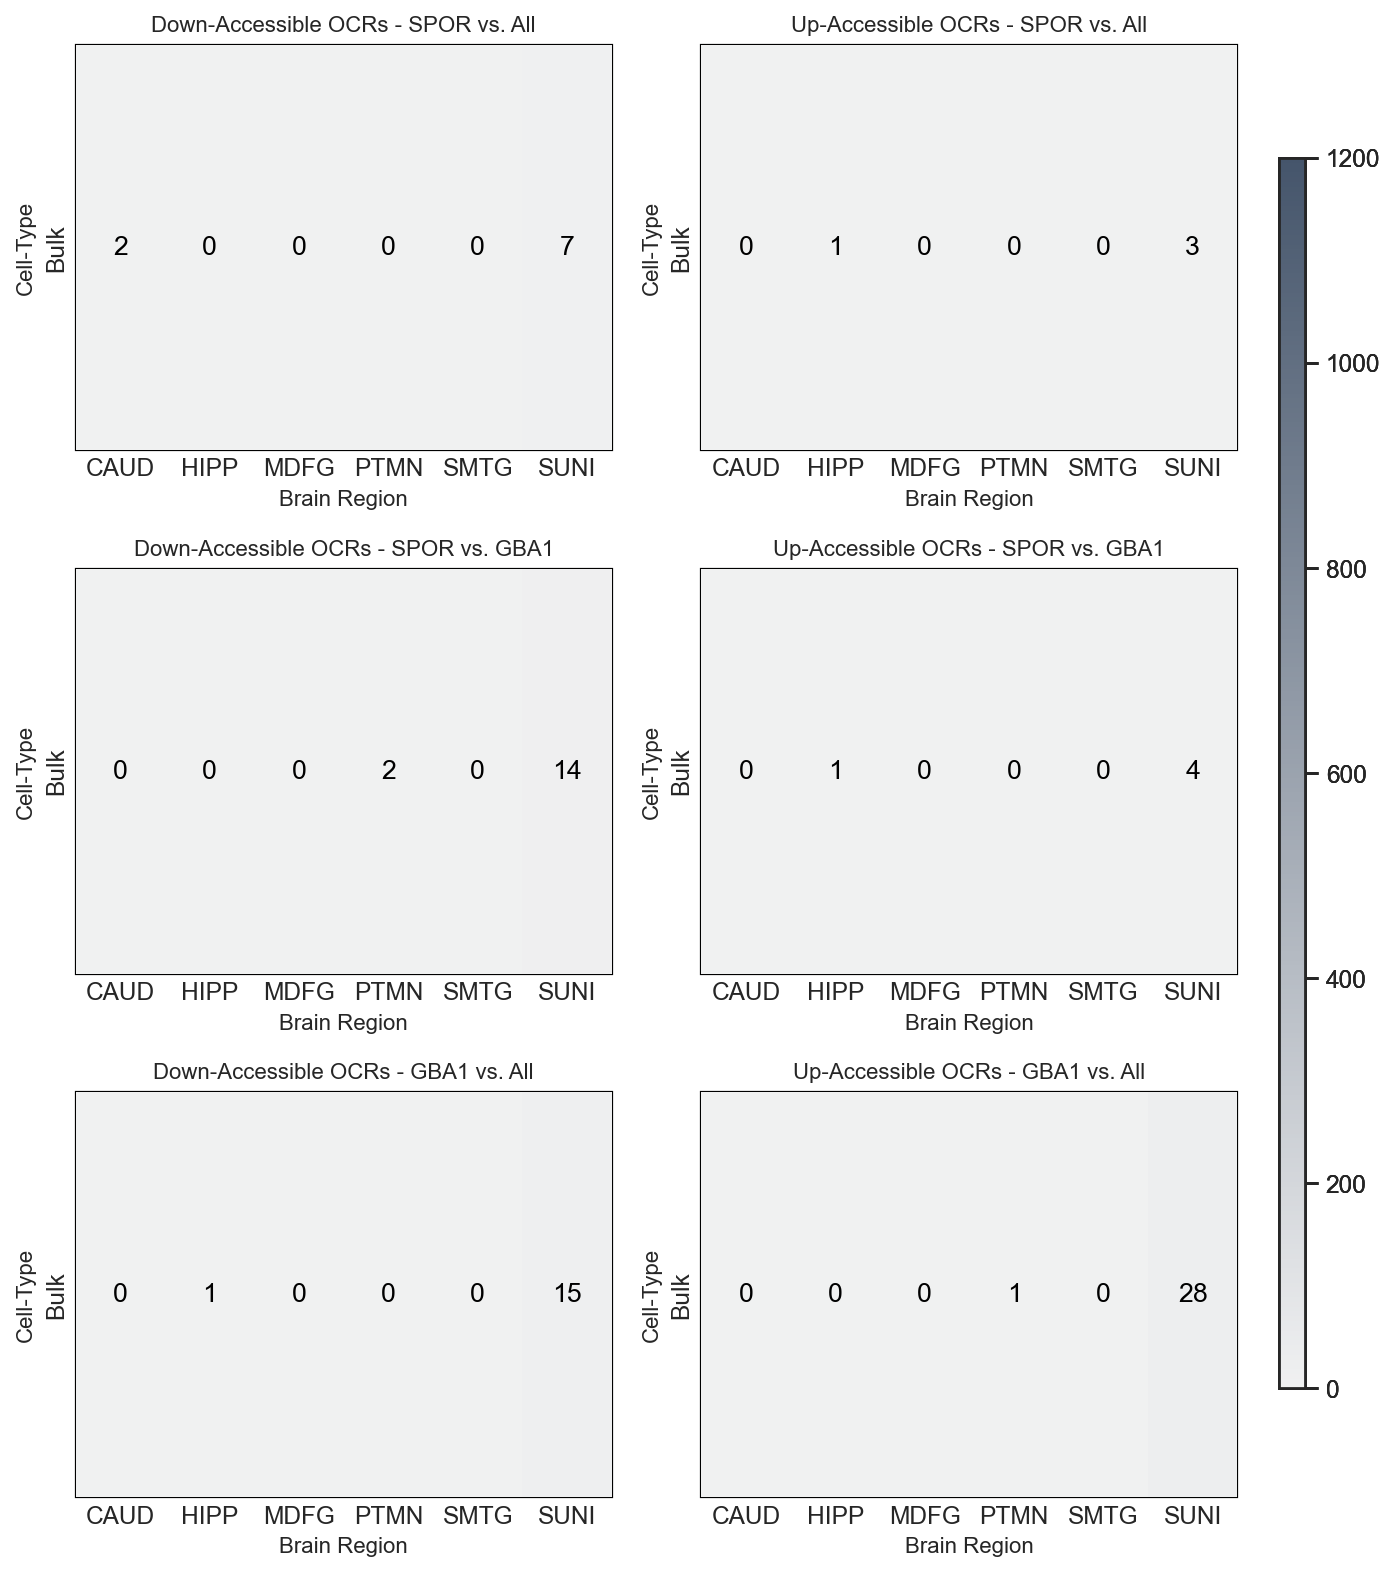

In [102]:
plot_DE_number(res_DE,
                       outdir,outname,#lf_key='log2FoldChange', 
                       cmap=cmap)

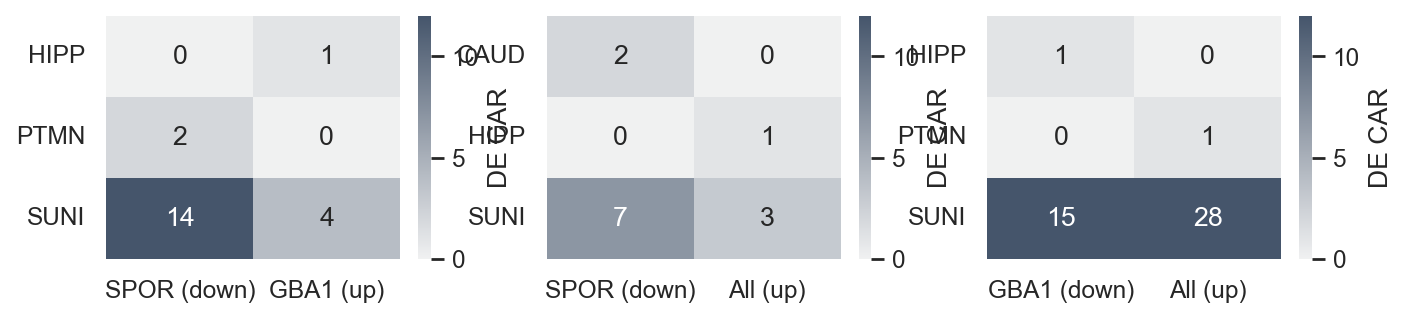

In [103]:
fig, axes = plt.subplots(1, 3,figsize=(10,2))
axes = axes.flatten()
for i, comp in enumerate(res_DE.comparison.unique()):
    ax = axes[i]
    c1,c2 = comp.split("$")
    toplot = res_DE[(res_DE.padj <=0.05) & (res_DE.comparison==comp)].groupby(["br","type_reg"]).size().unstack().fillna(0)[["down","up"]]
    toplot.rename(columns={"down":f"{c1} (down)", "up":f"{c2} (up)"},inplace=True)
    sns.heatmap(toplot,cmap=cmap, annot=True, cbar_kws={"label":"DE CAR"},ax=ax, vmin=0, vmax=12)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    # ax.set_title(comp)
plt.savefig("outdir/heatmap_bulk_DE_different_regions.svg")

In [104]:
res_DE[res_DE.padj <=0.05][[ 'geneStrand', 'geneId', 'transcriptId', 'distanceToTSS', 'ENSEMBL',"annotation",'SYMBOL', 'GENENAME', 'names', "br"]]
res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]
# res_DE

<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_56657/1445975495.py:2: SyntaxWarning: invalid escape sequence '\('
  res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]


In [105]:
tt = res_DE[res_DE.padj <=0.05][["annotation",'SYMBOL',"br", "comparison"]].reset_index()
tt.groupby(["br", "index"])["comparison"].nunique()

br    index                    
CAUD  chr1.240189356.240189705     1
      chr10.26850889.26851515      1
HIPP  chrY.56677051.56678886       3
PTMN  chr18.394699.395578          2
      chr6.168363393.168364211     1
SUNI  chr1.13819042.13820842       1
      chr1.151608276.151608643     3
      chr11.70628463.70629471      2
      chr12.109945015.109945329    1
      chr12.120092397.120094371    1
      chr12.123094255.123097026    1
      chr12.132837351.132838814    3
      chr12.2639925.2641487        2
      chr12.4808535.4810421        1
      chr12.68959499.68960832      2
      chr12.7158902.7159908        1
      chr13.106762669.106763526    1
      chr13.16016700.16018192      3
      chr14.33804972.33806105      2
      chr14.75452721.75453701      1
      chr14.95580785.95581867      1
      chr15.57550516.57551284      2
      chr15.74833294.74834552      1
      chr18.6221350.6222789        2
      chr18.62681748.62683179      1
      chr19.19541119.19541606      1
      

ab7697
4
['chr13.16016700.16018192', 'chr12.132837351.132838814', 'chr9.138021723.138023470', 'chr1.151608276.151608643', 'chr9.137741964.137743268', 'chr13.16016700.16018192', 'chr14.33804972.33806105', 'chr12.132837351.132838814', 'chr9.138021723.138023470', 'chr1.151608276.151608643', 'chr5.135577421.135579970', 'chr9.137881243.137882785', 'chr13.16016700.16018192', 'chr15.57550516.57551284', 'chr12.2639925.2641487', 'chr5.152461293.152462531', 'chr19.9846604.9848391', 'chr12.132837351.132838814', 'chr22.43848762.43849261', 'chrX.153530138.153531588', 'chr5.138595041.138597175', 'chr12.68959499.68960832', 'chr18.6221350.6222789', 'chr9.138021723.138023470', 'chr1.151608276.151608643', 'chr11.70628463.70629471', 'chr13.16016700.16018192', 'chr9.138021723.138023470', 'chr12.132837351.132838814', 'chr1.151608276.151608643']
['SNX27' 'GOLGA3' 'FAM230C' 'CACNA1B']


/Users/eloiseberson/miniconda3/envs/jupyter/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


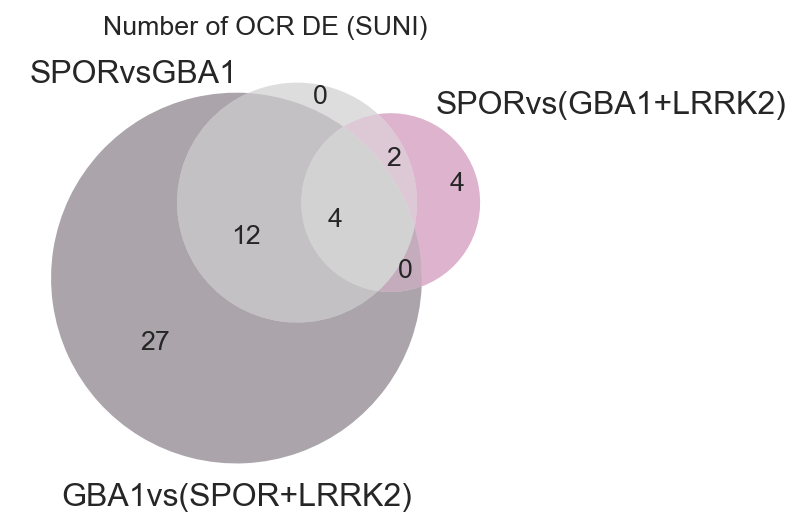

In [106]:
def combine_hex_values(d):
  d_items = sorted(d.items())
  tot_weight = sum(d.values())
  red = int(sum([int(k[:2], 16)*v for k, v in d_items])/tot_weight)
  green = int(sum([int(k[2:4], 16)*v for k, v in d_items])/tot_weight)
  blue = int(sum([int(k[4:6], 16)*v for k, v in d_items])/tot_weight)
  zpad = lambda x: x if len(x)==2 else '0' + x
  return zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])

dico_pk = {it:p for it,p in zip(res_DE.peakid,res_DE.SYMBOL)}
br="SUNI"
# ct="AST"
tmp = res_DE[(res_DE.br==br)&(res_DE.padj <=0.05)]
comp1 = tmp[tmp.comparison=="SPOR$GBA1"]
comp2= tmp[tmp.comparison=="SPOR$All"]
comp3 = tmp[tmp.comparison=="GBA1$All"]
palette={"GBA1vsAll":"#2D1E2F",  "SPORvsAll":"#AB4283","SPORvsGBA1":"#ababab"}


set1 = set(comp1.peakid.tolist())
set2=set(comp2.peakid.tolist())
set3=set(comp3.peakid.tolist())
v = venn3(subsets=[set1,set2,set3],
                 set_labels = ("SPORvsGBA1","SPORvs(GBA1+LRRK2)", "GBA1vs(SPOR+LRRK2)"))
v.get_patch_by_id('100').set_color(palette["SPORvsGBA1"])
v.get_patch_by_id('100').set_edgecolor('none')
v.get_patch_by_id('010').set_color(palette["SPORvsAll"])
v.get_patch_by_id('010').set_edgecolor('none')
v.get_patch_by_id('001').set_color(palette["GBA1vsAll"])
v.get_patch_by_id('001').set_edgecolor('none')

v110 = combine_hex_values({"ababab": 0.5, "AB4283": 0.5})
print(v110)
v.get_patch_by_id('110').set_color("#%s"%v110)
v.get_patch_by_id('110').set_edgecolor('none')

v101 = combine_hex_values({"ababab": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('101').set_color("#%s"%v101)
v.get_patch_by_id('101').set_edgecolor('none')

v011 = combine_hex_values({"AB4283": 0.5, "2D1E2F": 0.5})
v.get_patch_by_id('011').set_color("#%s"%v011)
v.get_patch_by_id('011').set_edgecolor('none')
plt.title("Number of OCR DE (%s)"%(br))

# v.get_label_by_id('110').set_text('\n'.join(set1 & set2 -set3))
# v.get_label_by_id('011').set_text('\n'.join(set2 & set3 -set1))
# v.get_label_by_id('101').set_text('\n'.join(set3 & set1 -set2))

peakss = list(set1 & set2 & set3)
peakss = [dico_pk[it] for it in peakss]
# v.get_label_by_id('111').set_text('\n'.join(peakss))


inter = [it for it in list(set1) if it in list(set2) if it in list(set3)]
print(len(inter))
inter2 = [it for it in list(set1) if it in list(set2)]
inter3 = [it for it in list(set1) if it in list(set3)]
inter4 = [it for it in list(set2) if it in list(set3) if it in list(set1)]
print(inter+inter2+inter3+inter4)
print(tmp[tmp.peakid.isin(inter)]["SYMBOL"].unique())

plt.savefig("./outdir/Bulk_Atac-seq_Venn_OCR_bulk__%s"%(br)+ ".svg", bbox_inches="tight")
plt.show()

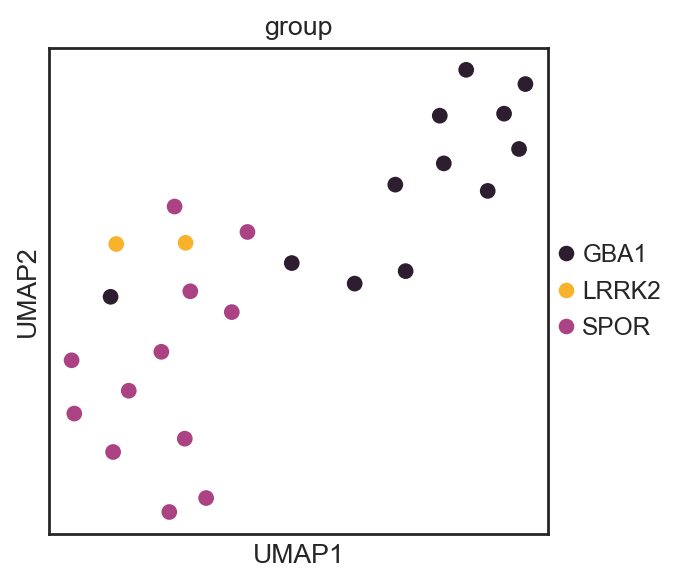

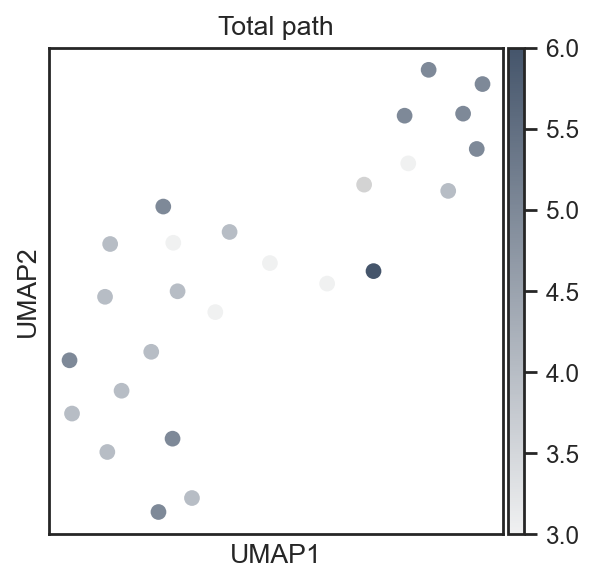

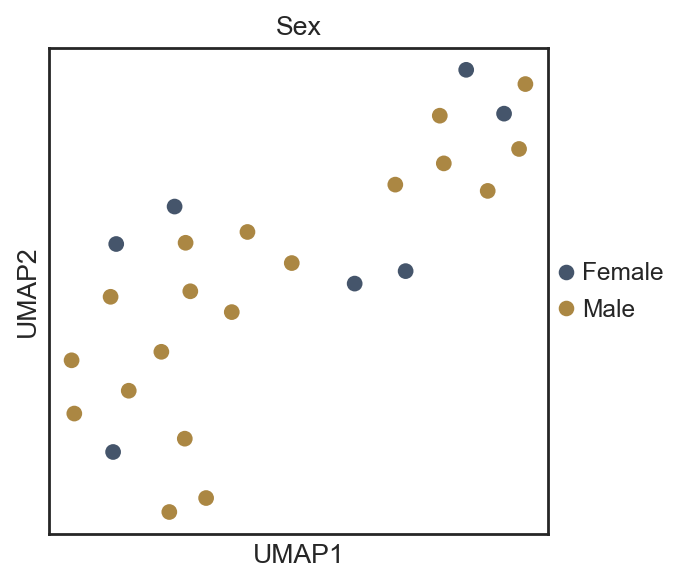

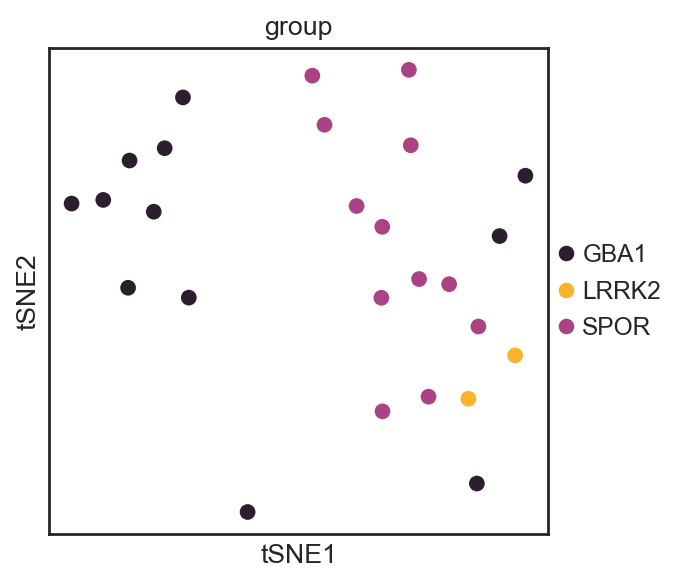

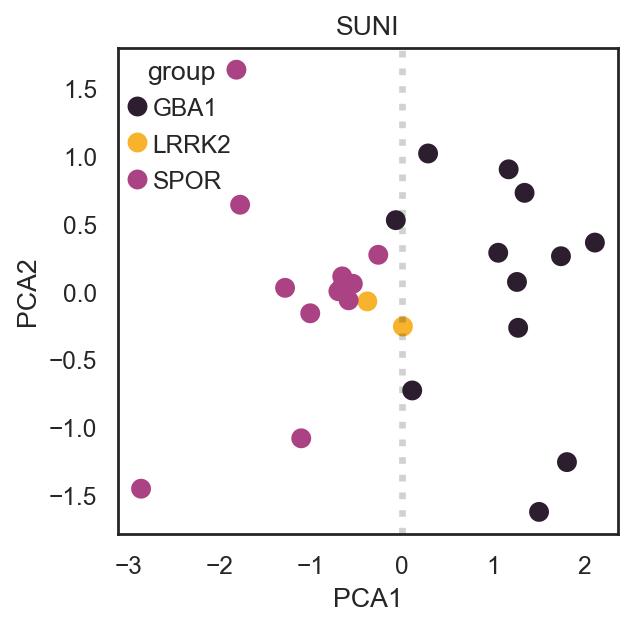

In [107]:
# adata.obs["Braak Score"] = adata.obs["xxx.Braak score"].map({"I":1, "II":1,"III":2, "IV":2, "V":3, "VI":3}).astype(float).values
# adata.obs["LB Stages"] = adata.obs['xxx.Unified LB Stage'].map({"0. No Lewy bodies":0.,"lV. Neocortical":3.,
#                                                      "lll. Brainstem/Limbic":2.,"lla. Brainstem Predominant":1.,
#                                                                "llb. Limbic Predominant":2.}).values
# adata.obs["Total path"] = adata.obs["Braak Score"].values.astype(float) + adata.obs["LB Stages"]
# adata.obs["Total path"] 
tmp_ad = adata[:, adata.var.peakid.isin(inter +inter2+inter3+inter4)]
tmp_ad = tmp_ad[(tmp_ad.obs.brain_region==br)] #&(tmp_ad.obs.condition.isin(["GBA1","SPOR","LRRK2"])) ,:]
sc.pp.neighbors(tmp_ad,n_neighbors=3)
sc.pp.pca(tmp_ad)
sc.tl.umap(tmp_ad)
sc.tl.tsne(tmp_ad,perplexity=5)
# sc.pl.pca(tmp_ad, color="condition",components="2,1",palette=COLORS_CT, s=100)
# sc.pl.pca(tmp_ad, color="condition",components="1,4",palette=COLORS_CT, s=100)
sc.pl.umap(tmp_ad, color=["group"],palette=COLORS_CT, s=200, save="BULK_PCA_DE_OCR_group_%s"%br)
sc.pl.umap(tmp_ad, color=["Total path"],cmap=cmap, s=200)
sc.pl.umap(tmp_ad, color=["Sex"], s=200, palette=COLORS_CT, save="BULK_PCA_DE_OCR_group_%s"%br)

sc.pl.tsne(tmp_ad, color="group",palette=COLORS_CT, s=200, save="BULK_PCA_DE_OCR_group_%s"%br)
# sce.tl.phate(tmp_ad, k=5,  t="auto", random_state=4)
# sce.pl.phate(tmp_ad,color=["group", "Total path"], s=200, ncols=2, wspace=0.4,
#              palette=COLORS_CT, cmap=cmap, save="BULK_PCA_DE_OCR_group_%s"%br,
             
#             )#cmap="BrBG"
# sce.pl.phate(tmp_ad,color=["MutationType"], s=200, ncols=2, wspace=0.4, 
#              save="BULK_PCA_DE_OCR_group_%s"%br,
#              palette=[
#                  # '#d60000',
 # '#ff62f7',
 # '#ac9c00',
 # '#740070',
 # # '#504900',
 # '#ff9a89',
 # '#907089',
 # # '#fff070',
 # '#cf0080',
 #    # '#823a31',
 # '#ffc1f4',
 # '#ba6b2f',
 # '#c6bf91',                 ]
             # palette=COLORS_CT, cmap=cmap_div,
            # )#cmap="BrBG"


from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(tmp_ad.X.astype(float))
tmp_ad.obs["PCA1"] =X_pca[:,0]
tmp_ad.obs["PCA2"] =X_pca[:,1]
ax = sns.scatterplot(tmp_ad.obs, x='PCA1', y='PCA2', hue="group",palette=COLORS_CT,s=80, 
                linewidth=0.0)#,labels={'0': 'LDA 1', '1': 'LDA 2'})
ax.axvline(x=0, linewidth=3,alpha=0.2, linestyle=":", c="k")
plt.title(br)
plt.savefig("./outdir/BULK_PCA_DE_OCR__%s"%(br)+ ".svg", bbox_inches="tight")
plt.show()


GBA1 vs. SPOR: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.658e-05 U_stat=1.440e+02


/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_56657/298581477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tt["group"] =tt["group"].astype(str)


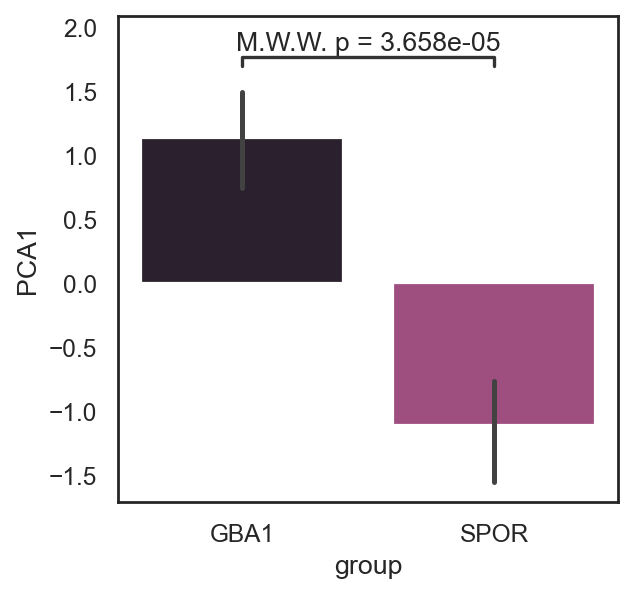

In [117]:
tt = tmp_ad.obs[tmp_ad.obs.group !="LRRK2"]
tt["group"] =tt["group"].astype(str)
ax = sns.barplot(data=tt, y="PCA1", x="group", hue="group", palette=COLORS_CT)
pairs=[("SPOR","GBA1")]
annotator= Annotator(pairs=pairs,ax=ax,data=tt, y="PCA1", x="group", hue="group",
                         order=['GBA1','SPOR'])
                         # order=['CTRL','GBA1','LRRK2','SPOR'])
annotator.configure(test='Mann-Whitney', text_format='full',comparisons_correction='Benjamini-Hochberg')
annotator.apply_and_annotate()
plt.savefig("./figures/barplot_PCA1_bulk_atac_seq_suni.svg")

In [76]:

tmp_ad.var.to_csv("Bulk_SUNI_DE_PEAKS_18.csv", index=None)
tmp_ad.var[["annotation","SYMBOL"]]#.SYMBOL.unique().tolist()
# tmp_ad

,annotation,SYMBOL
33734,Distal Intergenic,FAM230C
107851,"Intron (ENST00000663460.1/105378237, intron 1 ...",NMUR2
22852,"Intron (ENST00000663650.1/100874198, intron 1 ...",SHANK2-AS1
82907,"Intron (ENST00000330884.9/25830, intron 1 of 6)",SULT4A1
138798,"Exon (ENST00000371372.6/774, exon 3 of 47)",CACNA1B
7027,Distal Intergenic,SNX27
61104,3' UTR,PIN1
27009,Promoter,CACNA1C
106674,Promoter,SLC25A48
138806,"Exon (ENST00000371372.6/774, exon 19 of 47)",CACNA1B


AttributeError: 'NoneType' object has no attribute 'set_color'

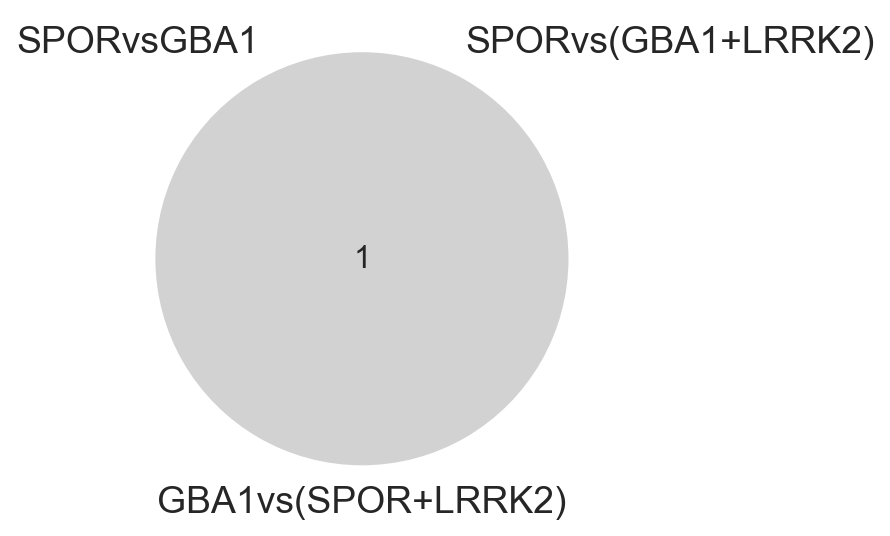

In [77]:
# def combine_hex_values(d):
#   d_items = sorted(d.items())
#   tot_weight = sum(d.values())
#   red = int(sum([int(k[:2], 16)*v for k, v in d_items])/tot_weight)
#   green = int(sum([int(k[2:4], 16)*v for k, v in d_items])/tot_weight)
#   blue = int(sum([int(k[4:6], 16)*v for k, v in d_items])/tot_weight)
#   zpad = lambda x: x if len(x)==2 else '0' + x
#   return zpad(hex(red)[2:]) + zpad(hex(green)[2:]) + zpad(hex(blue)[2:])


# br="HIPP"
# # ct="AST"
# tmp = res_DE[(res_DE.br==br)&(res_DE.padj <=0.05)]
# comp1 = tmp[tmp.comparison=="SPOR$GBA1"]
# comp2= tmp[tmp.comparison=="SPOR$All"]
# comp3 = tmp[tmp.comparison=="GBA1$All"]
# palette={"GBA1vsAll":"#2D1E2F",  "SPORvsAll":"#AB4283","SPORvsGBA1":"#ababab"}


# set1 = set(comp1.peakid.tolist())
# set2=set(comp2.peakid.tolist())
# set3=set(comp3.peakid.tolist())
# v = venn3(subsets=[set1,set2,set3],
#                  set_labels = ("SPORvsGBA1","SPORvs(GBA1+LRRK2)", "GBA1vs(SPOR+LRRK2)"))
# # v.get_patch_by_id('100').set_color(palette["SPORvsGBA1"])
# # v.get_patch_by_id('100').set_edgecolor('none')
# v.get_patch_by_id('010').set_color(palette["SPORvsAll"])
# v.get_patch_by_id('010').set_edgecolor('none')
# v.get_patch_by_id('001').set_color(palette["GBA1vsAll"])
# v.get_patch_by_id('001').set_edgecolor('none')

# v110 = combine_hex_values({"ababab": 0.5, "AB4283": 0.5})
# print(v110)
# # v.get_patch_by_id('110').set_color("#%s"%v110)
# # v.get_patch_by_id('110').set_edgecolor('none')

# v101 = combine_hex_values({"ababab": 0.5, "2D1E2F": 0.5})
# # v.get_patch_by_id('101').set_color("#%s"%v101)
# # v.get_patch_by_id('101').set_edgecolor('none')

# v011 = combine_hex_values({"AB4283": 0.5, "2D1E2F": 0.5})
# v.get_patch_by_id('011').set_color("#%s"%v011)
# v.get_patch_by_id('011').set_edgecolor('none')
# plt.title("Number of OCR DE in %s"%(br))

# inter = [it for it in list(set1) if it in list(set2) if it in list(set3)]
# print(len(inter))
# print(tmp[tmp.peakid.isin(inter)]["SYMBOL"].unique())

# plt.savefig("./outdir/Bulk_Venn_OCR_bulk__%s"%(br)+ ".svg", bbox_inches="tight")
# plt.show()

In [1]:
import pandas as pd
bulk_de_suni = pd.read_csv("Bulk_SUNI_DE_PEAKS_18.csv")
bulk_de_suni[["SYMBOL", "annotation"]]#.SYMBOL.unique()

,SYMBOL,annotation
0,FAM230C,Distal Intergenic
1,NMUR2,"Intron (ENST00000663460.1/105378237, intron 1 ..."
2,SHANK2-AS1,"Intron (ENST00000663650.1/100874198, intron 1 ..."
3,SULT4A1,"Intron (ENST00000330884.9/25830, intron 1 of 6)"
4,CACNA1B,"Exon (ENST00000371372.6/774, exon 3 of 47)"
5,SNX27,Distal Intergenic
6,PIN1,3' UTR
7,CACNA1C,Promoter
8,SLC25A48,Promoter
9,CACNA1B,"Exon (ENST00000371372.6/774, exon 19 of 47)"


In [8]:
# res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]
adata.var["annot"] = adata.var["annotation"].str.split(" \(", expand=True)[0]
# gene_list = res_DE[(res_DE.br=="SUNI") &(res_DE.padj<=0.05)].SYMBOL.astype(str).unique().tolist()
gene_list = bulk_de_suni.SYMBOL.astype(str).unique().tolist()
# gene_list = res_DE[(res_DE.br=="SUNI")].set_index("SYMBOL")[["log2FoldChange"]].sort_values("log2FoldChange",ascending=False)
adata.var.index = adata.var.index.astype(str)
adata.obs.index = adata.obs.index.astype(str)
bg = adata.var.SYMBOL.astype(str).unique().tolist()
enr = gp.enrich(gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 # permutation=10000,
                 # pheno_pos = "SPOR",
        # pheno_neg = "GBA1",
                 gene_sets=['KEGG_2021_Human'],#
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 # organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )
enr.res2d


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_12226/3845033855.py:2: SyntaxWarning: invalid escape sequence '\('
  adata.var["annot"] = adata.var["annotation"].str.split(" \(", expand=True)[0]


,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Type II diabetes mellitus,0.000336,0.011881,0,0,87.340351,698.647996,CACNA1B;CACNA1C
1,KEGG_2021_Human,Calcium signaling pathway,0.000448,0.011881,0,0,23.849421,183.877396,CACNA1B;ATP2B3;CACNA1C
2,KEGG_2021_Human,Arrhythmogenic right ventricular cardiomyopathy,0.001178,0.017912,0,0,45.400913,306.185607,CTNNA1;CACNA1C
3,KEGG_2021_Human,GABAergic synapse,0.001474,0.017912,0,0,40.403252,263.410541,CACNA1B;CACNA1C
4,KEGG_2021_Human,Aldosterone synthesis and secretion,0.001690,0.017912,0,0,37.639394,240.257908,ATP2B3;CACNA1C
5,KEGG_2021_Human,Serotonergic synapse,0.002247,0.018661,0,0,32.454902,197.912503,CACNA1B;CACNA1C
6,KEGG_2021_Human,Cholinergic synapse,0.002465,0.018661,0,0,30.932087,185.769398,CACNA1B;CACNA1C
7,KEGG_2021_Human,Dopaminergic synapse,0.003124,0.020196,0,0,27.337741,157.700245,CACNA1B;CACNA1C
8,KEGG_2021_Human,Retrograde endocannabinoid signaling,0.003429,0.020196,0,0,26.039895,147.785592,CACNA1B;CACNA1C
9,KEGG_2021_Human,Adrenergic signaling in cardiomyocytes,0.004194,0.022228,0,0,23.441135,128.319602,ATP2B3;CACNA1C


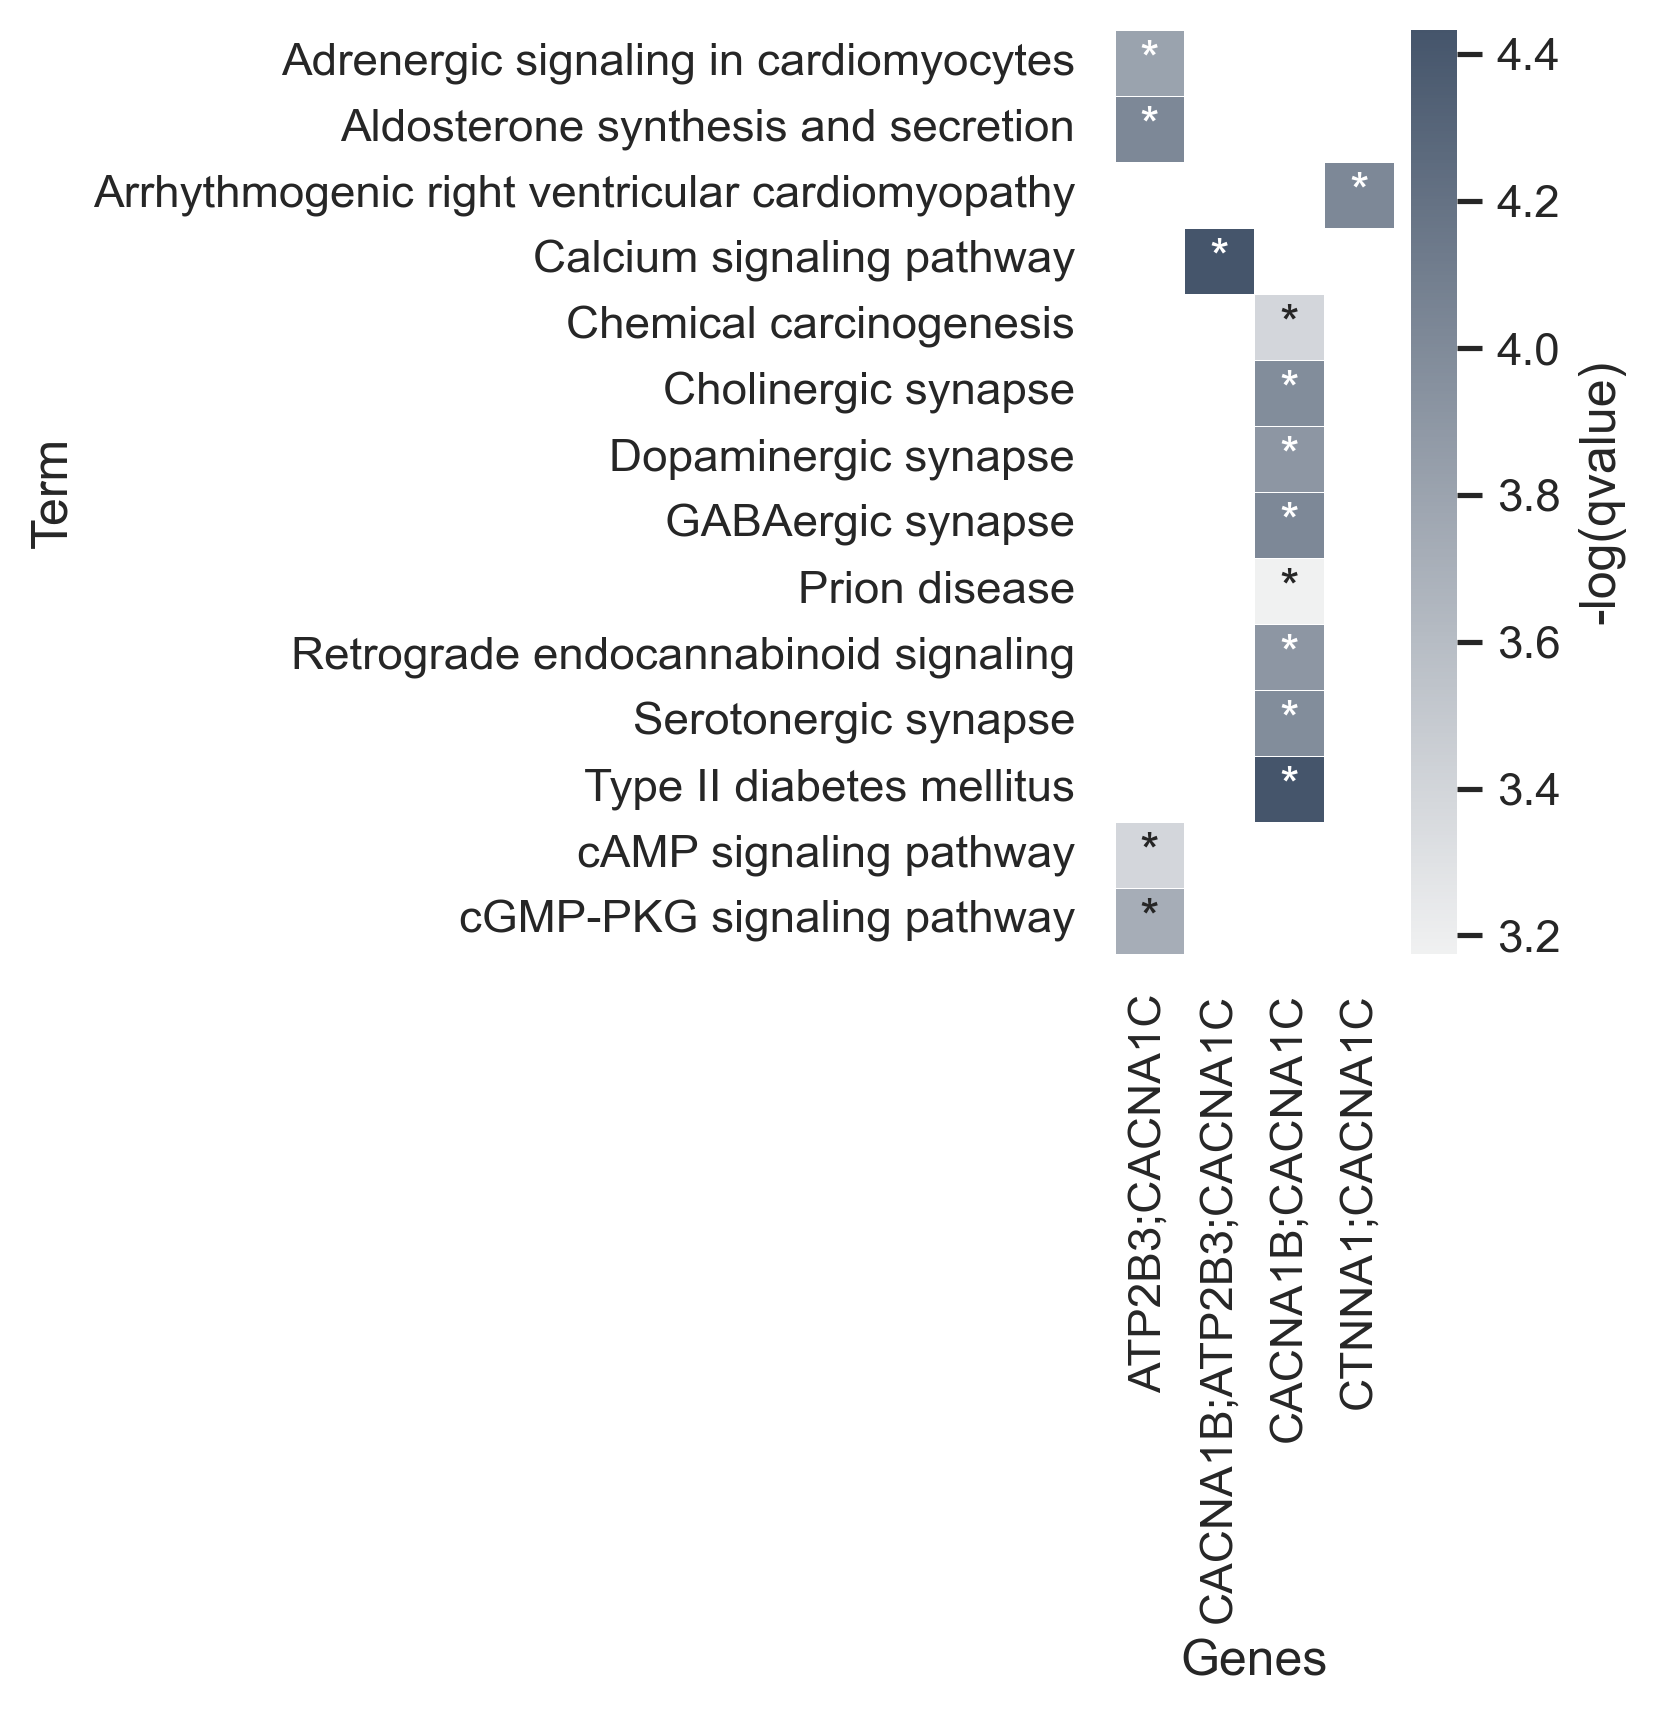

In [16]:
def pval_f(x):
    if x>=-np.log(0.0001):
        return "****"
    elif x>=-np.log(0.001):
        return "***"
    elif x>=-np.log( 0.01):
        return "**"
    elif x>=-np.log(0.05):
        return "*"
    else:
        return ""




term = enr.res2d.copy()
term["Number of genes"] = term["Genes"].apply(lambda x : len(x.split(";")))
term["-log(qvalue)"] = -np.log(term['Adjusted P-value'])
ht = pd.pivot_table(data=term[(term['Adjusted P-value']<=0.05) &(term["Number of genes"]>1)], values='-log(qvalue)', index=['Genes'],
                       columns=["Term"])

annot = ht.copy()
for it in ht.columns.tolist():
    annot[it] = annot[it].apply(lambda x: pval_f(x)).tolist()
fig, ax = plt.subplots(figsize=(1.5,4))
sns.set(font_scale=1, style="white")

sns.heatmap(ht.T, cmap=cmap, annot=annot.T,fmt="s",
            ax=ax,linewidth=0.2, cbar_kws={"label":"-log(qvalue)"})

fig.savefig("outdir/heatmap_bulk_enrichr_suni.svg")

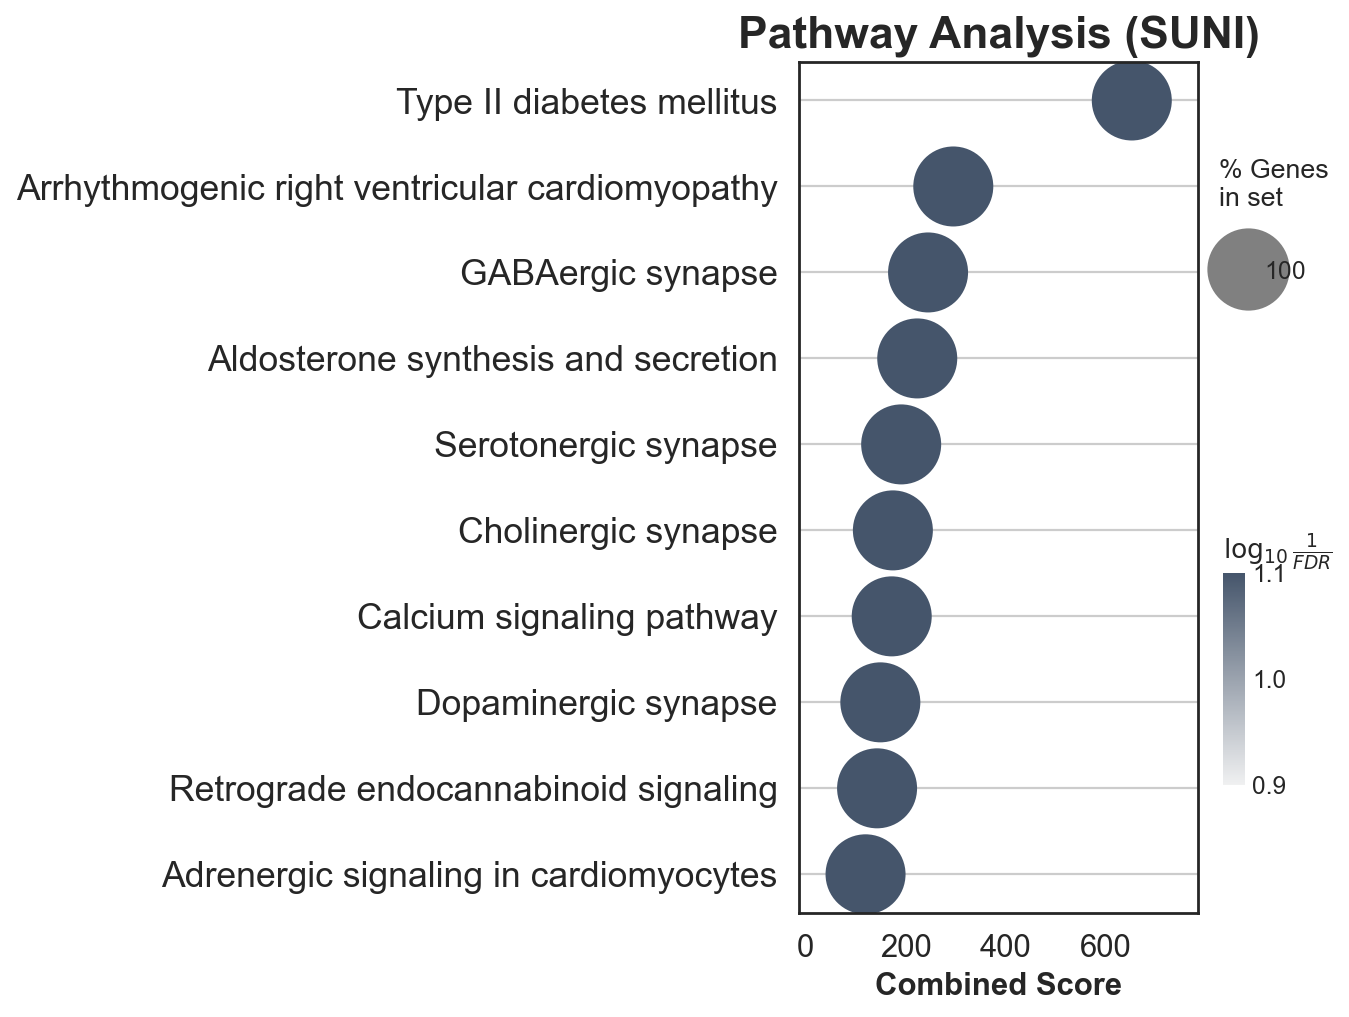

In [81]:
ax = gp.dotplot(enr.res2d,
             # column="-log(Qvalue)",
                # column="Adjusted ",
                column="Adjusted P-value",
             title='Pathway Analysis (SUNI)',
             cmap=cmap,
              top_term=10,
             size=6, # adjust dot size
             figsize=(4,7), cutoff=0.05, show_ring=False)

In [82]:
import gseapy as gp
res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]
adata.var["annot"] = adata.var["annotation"].str.split(" \(", expand=True)[0]
# gene_list = res_DE[(res_DE.brain_region=="SUNI") &(res_DE.padj<=0.05)].SYMBOL.astype(str).unique().tolist()
gene_list = res_DE[(res_DE.br=="SUNI")].set_index("SYMBOL")[["log2FoldChange"]].sort_values("log2FoldChange",ascending=False)
adata.var.index = adata.var.index.astype(str)
adata.obs.index = adata.obs.index.astype(str)
bg = adata.var.SYMBOL.astype(str).unique().tolist()
enr = gp.prerank(rnk=gene_list, # or "./tests/data/gene_list.txt",
                 background=bg,
                 permutation=10000,
                 pheno_pos = "SPOR",
        pheno_neg = "GBA1",
                 gene_sets=['KEGG_2021_Human'],#
                 # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                )
enr.res2d

<>:2: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_56657/3344514287.py:2: SyntaxWarning: invalid escape sequence '\('
  res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]
/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_56657/3344514287.py:3: SyntaxWarning: invalid escape sequence '\('
  adata.var["annot"] = adata.var["annotation"].str.split(" \(", expand=True)[0]
2024-12-19 16:17:53,300 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,KEGG_2021_Human__MAPK signaling pathway,0.791477,4.36319,0.0,0.0,0.0,236/274,15.45%,PTPN7;MAP2K2;PDGFB;CACNA1B;ANGPT4;VEGFB;CACNG2...
1,prerank,KEGG_2021_Human__Pathways of neurodegeneration,0.741665,4.302004,0.0,0.0,0.0,331/427,16.10%,GRIA1;ATP2A3;KLC1;MAP2K2;COX6B2;CACNA1B;CACNA1...
2,prerank,KEGG_2021_Human__Calcium signaling pathway,0.793588,4.275749,0.0,0.0,0.0,194/225,15.45%,ATP2A3;PDGFB;ATP2B2;CACNA1B;VEGFB;NOS3;CACNA1C...
3,prerank,KEGG_2021_Human__Neuroactive ligand-receptor i...,0.768548,4.257348,0.0,0.0,0.0,235/292,16.28%,NMUR2;GRM2;C3;GRIA1;PYY;PRLH;CHRNB2;SSTR3;OPRD...
4,prerank,KEGG_2021_Human__Axon guidance,0.812506,4.232505,0.0,0.0,0.0,148/180,11.10%,UNC5C;NTN1;PLXNB2;SEMA3F;PDPK1;SEMA6B;PRKCA;SE...
...,...,...,...,...,...,...,...,...,...,...
299,prerank,KEGG_2021_Human__Asthma,0.700664,2.290925,0.0,0.0,0.0,16/20,25.29%,HLA-DRB1;HLA-DPA1;CD40;HLA-DOA;IL13;HLA-DPB1;H...
300,prerank,KEGG_2021_Human__Protein export,0.714262,2.278348,0.0,0.0,0.0,17/18,26.54%,IMMP2L;SPCS3;SRP19;SEC61G;SEC61A1;SRP68;SRP9;S...
301,prerank,KEGG_2021_Human__Maturity onset diabetes of th...,0.737885,2.274982,0.0,0.0,0.0,14/17,20.55%,GCK;NR5A2;NEUROD1;HNF4G;HES1;HHEX;RFX6;SLC2A2;...
302,prerank,KEGG_2021_Human__Nitrogen metabolism,0.705442,2.165614,0.0,0.0,0.0,9/16,13.18%,CA4;CA5A;CA9;CPS1;CA12;CA7;CA5B;CA1;GLUL


In [ ]:
enr.res2d[20:50]

In [ ]:
term = enr.res2d.copy()
term.Term = term.Term.str.replace("KEGG_2021_Human__","")
ax = gp.dotplot(term,
             # column="-log(Qvalue)",
                column="FDR q-val",
             title='Pathway Analysis (SUNI)',
             cmap=plt.cm.viridis,
              top_term=20,
             size=6, # adjust dot size
             figsize=(4,6), cutoff=0.01, show_ring=False)

In [ ]:
terms = enr.res2d.Term
axs = enr.plot(terms=terms[:3], figsize=(6,4), colors="#704c5e",
            ) # v1.0.5


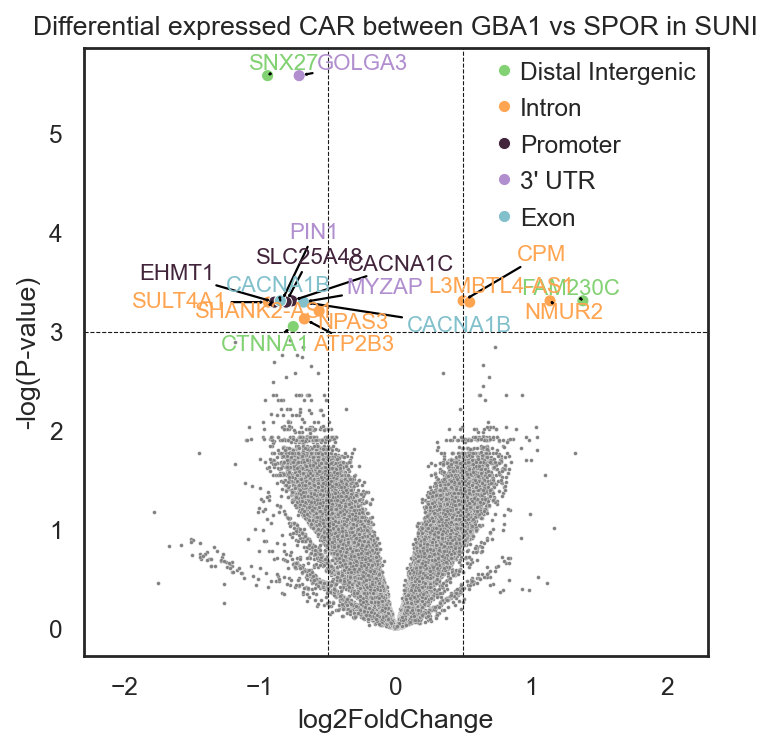

In [98]:
pal = {"3' UTR":"#b18fcf","Promoter":"#42253b", "Intron":"#ffa552","Exon":"#82c0cc","Distal Intergenic":"#82d173"}

res_DE["-log(P-value)"] = -np.log(res_DE["padj"])
toplot = res_DE[(res_DE.br=="SUNI")&(res_DE.comparison=="SPOR$GBA1")]
sns.set(style="white")
fig, ax = plt.subplots(figsize=(5,5))
x="log2FoldChange"
y="-log(P-value)"
sns.scatterplot(data = toplot[toplot.padj>0.05], x=x, y=y, color="gray", s=3)
sns.scatterplot(data = toplot[toplot.padj<=0.05], x=x, y=y, color="gray", s=30, hue="annot", palette=pal)
ax.axhline(y=-np.log(0.05), c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=-0.5, c="k", linestyle="--", linewidth=0.5)
ax.axvline(x=0.5, c="k", linestyle="--", linewidth=0.5)
ax.legend(bbox_to_anchor=(1,1))

texts = []
for i, it in enumerate(toplot[toplot.padj<=0.05].iterrows()):
    text = plt.text(it[1][x], it[1][y], it[1]["SYMBOL"], fontsize=10, color=pal[it[1]["annot"]])
    texts.append(text)

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black'))
ax.set_xlim(-2.3,2.3)
ax.set_title("Differential expressed CAR between GBA1 vs SPOR in SUNI")
plt.savefig("outdir/volcano_bulk_DE_SUNI.svg")